# Análise e Previsão de Preços de Laptops

## Dataset
- https://www.kaggle.com/datasets/ehtishamsadiq/uncleaned-laptop-price-dataset
## Objetivos
**Principal:** Desenvolver um modelo de machine learning capaz de prever o preço de um laptop com base em suas especificações técnicas, com um erro médio inferior a 7500,00.

**Resultado Alcançado:** MAE = **8.275,11** com XGBoost

**Objetivos Secundários:**
- ✅ Identificar e quantificar o impacto das principais características no preço final
- ✅ Realizar análise exploratória detalhada para extrair insights sobre o mercado de laptops
- ✅ Comparar modelos baseline com modelos mais avançados (Random Forest, XGBoost)
- ✅ Otimizar hiperparâmetros para maximizar performance

## 📑 Índice

1. **Import das Bibliotecas**
2. **Carrega e Explora o Dataset**
3. **Limpeza dos Dados e Pré-Processamento**
4. **Análise Exploratória de Dados (EDA)**
   - 4.1 Análise da Variável Target (Price)
   - 4.2 Análise de Variáveis Categóricas
   - 4.3 Análise de Correlações
5. **Identificação de Outliers**
6. **Tratamento de Outliers**
7. **Feature Engineering**
8. **Seleção de Features e Preparação para Modelagem**
9. **Treino da Baseline (Linear Regression)**
10. **Modelagem Avançada**
    - 10.1 Random Forest Inicial
    - 10.2 Otimização de Hiperparâmetros - Random Forest
    - 10.3 Gradient Boosting Regressor
    - 10.4 XGBoost - Modelo Avançado
    - 10.5 Análise de Erros - Identificando Padrões de Erro
11. **Comparação Final dos Modelos**
12. **Conclusão e Insights**

---

## 1. Import das Bibliotecas


Esta seção é dedicada à importação de todas as bibliotecas Python necessárias para o projeto. Inclui ferramentas para manipulação de dados (pandas, numpy), visualização (matplotlib, seaborn) e machine learning (sklearn, xgboost).

In [ ]:
# @title
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np
import re

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Bibliotecas para machine learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import time
from sklearn.model_selection import GridSearchCV

# Configurações
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ Bibliotecas importadas com sucesso!")

✓ Bibliotecas importadas com sucesso!


## 2. Carrega e explora o dataset


Nesta etapa, o dataset de preços de laptops é carregado na memória e as primeiras observações são feitas sobre sua estrutura, dimensão e o formato dos dados. Isso nos permite ter um entendimento inicial dos dados com os quais vamos trabalhar.

In [ ]:
# @title
# Carregar o dataset
df = pd.read_csv('laptopData.csv')

print("="*80)
print("INFORMAÇÕES BÁSICAS DO DATASET")
print("="*80)
print(f"\nShape: {df.shape}")
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
print("\n" + "="*80)
print("PRIMEIRAS 10 LINHAS")
print("="*80)
df.head(10)

INFORMAÇÕES BÁSICAS DO DATASET

Shape: (1303, 12)
Linhas: 1303 | Colunas: 12

PRIMEIRAS 10 LINHAS


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
5,5.0,Acer,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4GB,500GB HDD,AMD Radeon R5,Windows 10,2.1kg,21312.0000
6,6.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.2GHz,16GB,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04kg,114017.6016
7,7.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,61735.5360
8,8.0,Asus,Ultrabook,14,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,512GB SSD,Nvidia GeForce MX150,Windows 10,1.3kg,79653.6000
9,9.0,Acer,Ultrabook,14,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,Intel UHD Graphics 620,Windows 10,1.6kg,41025.6000


In [ ]:
# @title
# Informações sobre tipos de dados e valores nulos
print("="*80)
print("INFORMAÇÕES DOS DADOS")
print("="*80)
df.info()

print("\n" + "="*80)
print("VALORES NULOS POR COLUNA")
print("="*80)
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100
null_info = pd.DataFrame({
    'Valores Nulos': null_counts,
    'Percentual (%)': null_percentages
})
print(null_info[null_info['Valores Nulos'] > 0] if null_info['Valores Nulos'].sum() > 0 else "✓ Nenhum valor nulo encontrado!")

INFORMAÇÕES DOS DADOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   object 
 2   TypeName          1273 non-null   object 
 3   Inches            1273 non-null   object 
 4   ScreenResolution  1273 non-null   object 
 5   Cpu               1273 non-null   object 
 6   Ram               1273 non-null   object 
 7   Memory            1273 non-null   object 
 8   Gpu               1273 non-null   object 
 9   OpSys             1273 non-null   object 
 10  Weight            1273 non-null   object 
 11  Price             1273 non-null   float64
dtypes: float64(2), object(10)
memory usage: 122.3+ KB

VALORES NULOS POR COLUNA
                  Valores Nulos  Percentual (%)
Unnamed: 0                   30        2.302379
Company                      30     

In [ ]:
# @title
# Estatísticas descritivas
print("="*80)
print("ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS NUMÉRICAS")
print("="*80)
df.describe().T

ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1273.0,652.674784,376.493027,0.00,327.00,652.00,980.0000,1302.00
Price,1273.0,59955.814073,37332.251005,9270.72,31914.72,52161.12,79333.3872,324954.72


## 3. Limpeza dos Dados e Pré-Processamento


A fase de limpeza e pré-processamento é crucial para garantir a qualidade dos dados. Aqui, removemos colunas desnecessárias, tratamos valores nulos preenchendo-os com a mediana, e convertemos tipos de dados (`Inches`, `Weight`, `Ram`, `Price`) para formatos numéricos adequados para análise e modelagem.

In [ ]:
# @title
# Criar uma cópia para trabalhar
df_clean = df.copy()

# Remover coluna 'Unnamed: 0' (índice)
if 'Unnamed: 0' in df_clean.columns:
    df_clean = df_clean.drop('Unnamed: 0', axis=1)
    print("✓ Coluna 'Unnamed: 0' removida")

# Verificar e limpar linhas vazias
rows_before = len(df_clean)
df_clean = df_clean.dropna(how='all')
rows_after = len(df_clean)
if rows_before > rows_after:
    print(f"✓ Removidas {rows_before - rows_after} linhas completamente vazias")

# Extrair valor numérico de Inches (tratar valores inválidos)
df_clean['Inches'] = pd.to_numeric(df_clean['Inches'], errors='coerce')
inches_median = df_clean['Inches'].median()
df_clean['Inches'] = df_clean['Inches'].fillna(inches_median)
print(f"✓ Inches: Valores inválidos preenchidos com mediana ({inches_median:.2f} polegadas)")

# Extrair valor numérico de Weight (remover 'kg' e tratar valores inválidos)
df_clean['Weight'] = df_clean['Weight'].str.replace('kg', '', regex=False)
df_clean['Weight'] = pd.to_numeric(df_clean['Weight'], errors='coerce')
weight_median = df_clean['Weight'].median()
df_clean['Weight'] = df_clean['Weight'].fillna(weight_median)
print(f"✓ Weight: Convertido para float, valores inválidos preenchidos com mediana ({weight_median:.2f}kg)")

# Extrair valor numérico de Ram (remover 'GB' e tratar valores inválidos)
df_clean['Ram'] = df_clean['Ram'].str.replace('GB', '', regex=False)
df_clean['Ram'] = pd.to_numeric(df_clean['Ram'], errors='coerce')
ram_median = df_clean['Ram'].median()
df_clean['Ram'] = df_clean['Ram'].fillna(ram_median)
print(f"✓ Ram: Convertido para int, valores inválidos preenchidos com mediana ({int(ram_median)}GB)")

# Tratar coluna Price também
df_clean['Price'] = pd.to_numeric(df_clean['Price'], errors='coerce')
price_median = df_clean['Price'].median()
df_clean['Price'] = df_clean['Price'].fillna(price_median)
print(f"✓ Price: Valores inválidos preenchidos com mediana ({price_median:.2f})")

print(f"\n✓ Limpeza básica concluída!")
print(f"Shape final: {df_clean.shape}")
df_clean.head()

✓ Coluna 'Unnamed: 0' removida
✓ Removidas 30 linhas completamente vazias
✓ Inches: Valores inválidos preenchidos com mediana (15.60 polegadas)
✓ Weight: Convertido para float, valores inválidos preenchidos com mediana (2.04kg)
✓ Ram: Convertido para int, valores inválidos preenchidos com mediana (8GB)
✓ Price: Valores inválidos preenchidos com mediana (52161.12)

✓ Limpeza básica concluída!
Shape final: (1273, 11)


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080


## 4. EDA

### 4.1 Análise da Variável Target (Price)

Aqui, exploramos a variável alvo 'Price' para entender sua distribuição, estatísticas descritivas e identificar possíveis anomalias. A visualização por histogramas e boxplots nos ajuda a compreender a natureza dos preços dos laptops no dataset.

ESTATÍSTICAS DA VARIÁVEL TARGET - PRICE
Média: 59955.81
Mediana: 52161.12
Desvio Padrão: 37332.25
Mínimo: 9270.72
Máximo: 324954.72
Amplitude: 315684.00


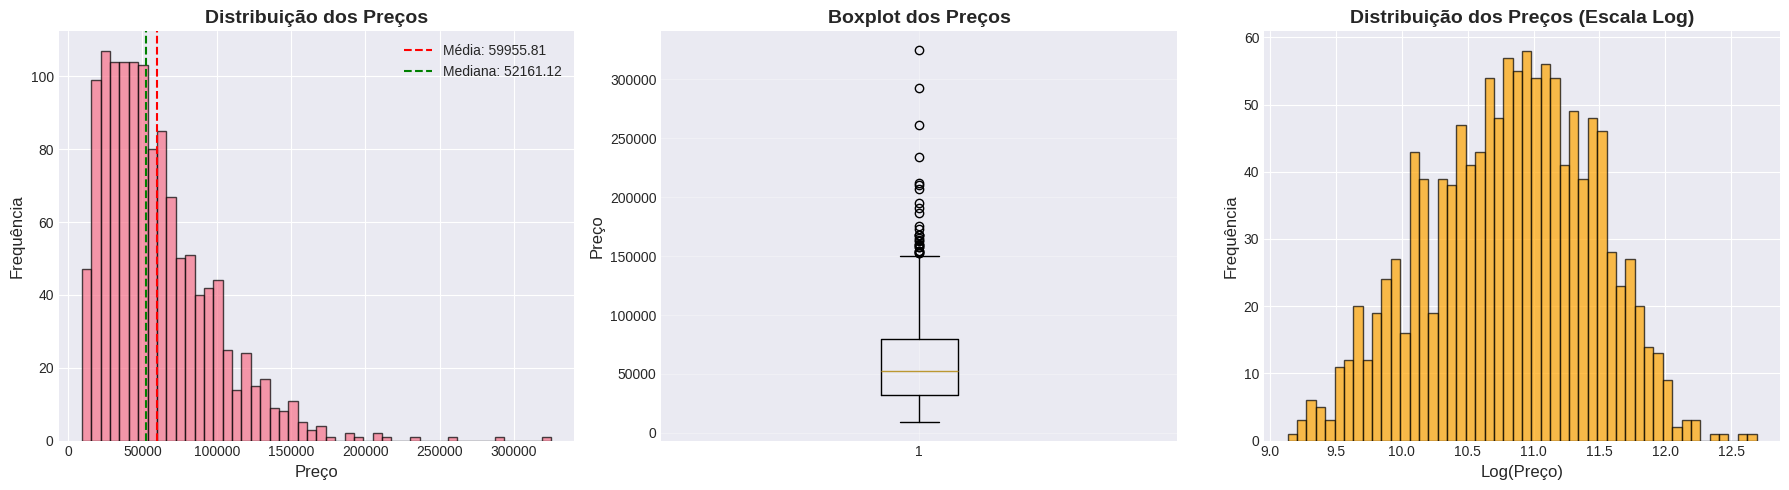

In [ ]:
# @title
# Estatísticas do preço
print("="*80)
print("ESTATÍSTICAS DA VARIÁVEL TARGET - PRICE")
print("="*80)
print(f"Média: {df_clean['Price'].mean():.2f}")
print(f"Mediana: {df_clean['Price'].median():.2f}")
print(f"Desvio Padrão: {df_clean['Price'].std():.2f}")
print(f"Mínimo: {df_clean['Price'].min():.2f}")
print(f"Máximo: {df_clean['Price'].max():.2f}")
print(f"Amplitude: {df_clean['Price'].max() - df_clean['Price'].min():.2f}")

# Visualização da distribuição do preço
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
axes[0].hist(df_clean['Price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Preço', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)
axes[0].set_title('Distribuição dos Preços', fontsize=14, fontweight='bold')
axes[0].axvline(df_clean['Price'].mean(), color='red', linestyle='--', label=f'Média: {df_clean["Price"].mean():.2f}')
axes[0].axvline(df_clean['Price'].median(), color='green', linestyle='--', label=f'Mediana: {df_clean["Price"].median():.2f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df_clean['Price'], vert=True)
axes[1].set_ylabel('Preço', fontsize=12)
axes[1].set_title('Boxplot dos Preços', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Log scale
axes[2].hist(np.log1p(df_clean['Price']), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[2].set_xlabel('Log(Preço)', fontsize=12)
axes[2].set_ylabel('Frequência', fontsize=12)
axes[2].set_title('Distribuição dos Preços (Escala Log)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 4.2 Análise de Variáveis Categóricas

Esta subseção foca na análise das variáveis categóricas como 'Company', 'TypeName' e 'OpSys'. Examinamos a distribuição de frequência de cada categoria e como elas se relacionam com o preço, utilizando gráficos de barras para visualizar os insights.

COMPANY - Distribuição
Company
Lenovo       290
Dell         287
HP           266
Asus         156
Acer         103
MSI           53
Toshiba       47
Apple         21
Samsung        9
Mediacom       7
Razer          7
Microsoft      6
Vero           4
Xiaomi         4
Chuwi          3
LG             3
Google         3
Huawei         2
Fujitsu        2
Name: count, dtype: int64

Total de categorias únicas: 19


TYPENAME - Distribuição
TypeName
Notebook              710
Gaming                203
Ultrabook             191
2 in 1 Convertible    116
Workstation            29
Netbook                24
Name: count, dtype: int64

Total de categorias únicas: 6


OPSYS - Distribuição
OpSys
Windows 10      1047
No OS             63
Linux             61
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            1
Name: count, dtype: int64

Total de categorias únicas: 9




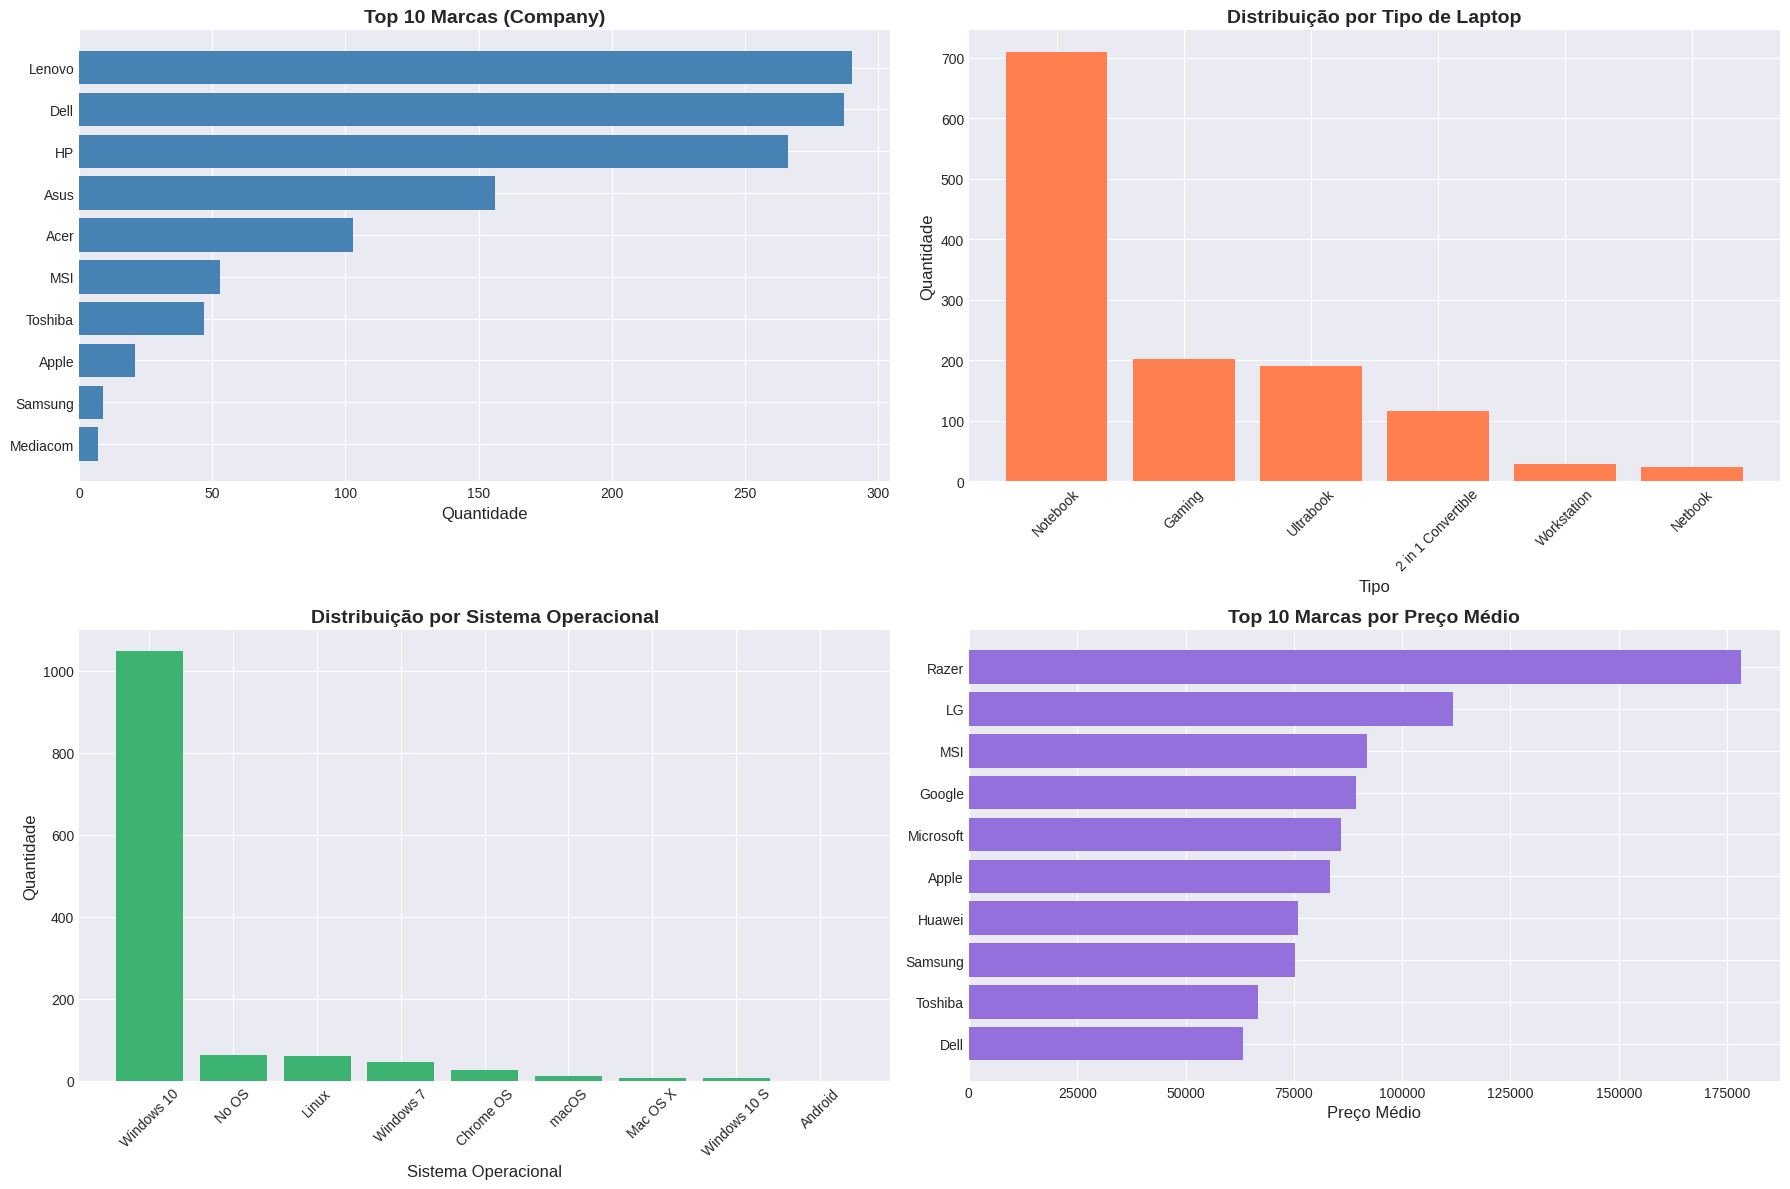

In [ ]:
# @title
# Analisar variáveis categóricas
categorical_cols = ['Company', 'TypeName', 'OpSys']

for col in categorical_cols:
    print("="*80)
    print(f"{col.upper()} - Distribuição")
    print("="*80)
    value_counts = df_clean[col].value_counts()
    print(value_counts)
    print(f"\nTotal de categorias únicas: {df_clean[col].nunique()}")
    print("\n")

# Visualizar distribuição das principais variáveis categóricas
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Company
company_counts = df_clean['Company'].value_counts().head(10)
axes[0, 0].barh(company_counts.index, company_counts.values, color='steelblue')
axes[0, 0].set_xlabel('Quantidade', fontsize=12)
axes[0, 0].set_title('Top 10 Marcas (Company)', fontsize=14, fontweight='bold')
axes[0, 0].invert_yaxis()

# TypeName
type_counts = df_clean['TypeName'].value_counts()
axes[0, 1].bar(type_counts.index, type_counts.values, color='coral')
axes[0, 1].set_xlabel('Tipo', fontsize=12)
axes[0, 1].set_ylabel('Quantidade', fontsize=12)
axes[0, 1].set_title('Distribuição por Tipo de Laptop', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

# OpSys
opsys_counts = df_clean['OpSys'].value_counts()
axes[1, 0].bar(opsys_counts.index, opsys_counts.values, color='mediumseagreen')
axes[1, 0].set_xlabel('Sistema Operacional', fontsize=12)
axes[1, 0].set_ylabel('Quantidade', fontsize=12)
axes[1, 0].set_title('Distribuição por Sistema Operacional', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

# Preço médio por Company (Top 10)
price_by_company = df_clean.groupby('Company')['Price'].mean().sort_values(ascending=False).head(10)
axes[1, 1].barh(price_by_company.index, price_by_company.values, color='mediumpurple')
axes[1, 1].set_xlabel('Preço Médio', fontsize=12)
axes[1, 1].set_title('Top 10 Marcas por Preço Médio', fontsize=14, fontweight='bold')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

### 4.3 Análise de Correlações (Variáveis Numéricas Básicas)

Analisamos as correlações entre as variáveis numéricas principais e a variável alvo 'Price'. Utilizando uma matriz de correlação e scatter plots, identificamos quais características numéricas têm maior influência no preço, como 'Ram' e 'SSD_GB'.

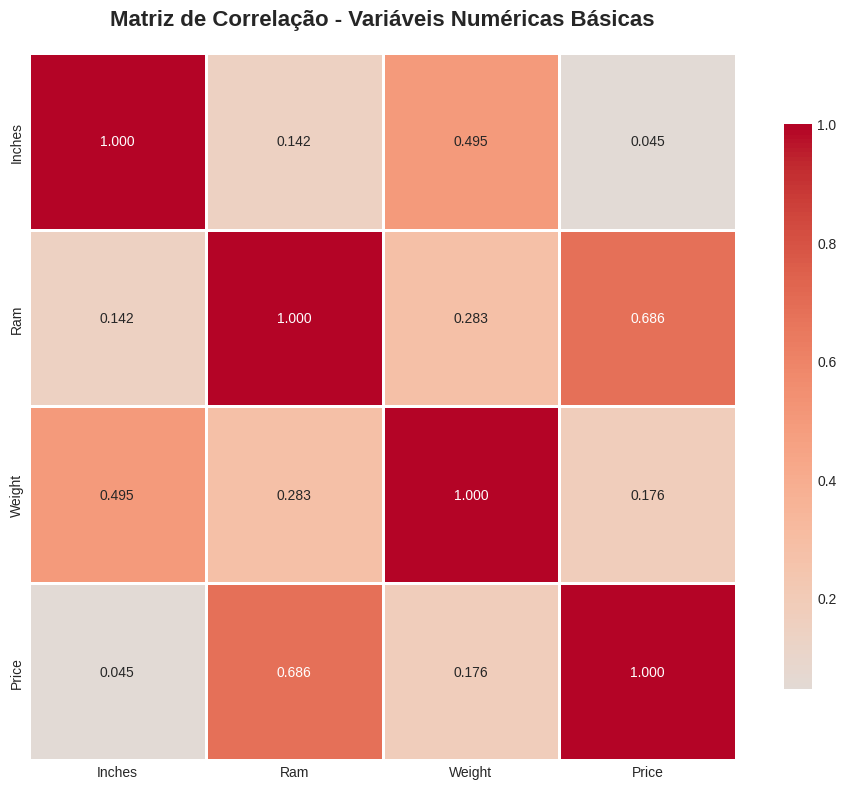

CORRELAÇÕES COM O PREÇO (PRICE)
Price     1.000000
Ram       0.685648
Weight    0.175896
Inches    0.044966
Name: Price, dtype: float64


In [ ]:
# @title
# Selecionar apenas colunas numéricas para correlação
numeric_cols = ['Inches', 'Ram', 'Weight', 'Price']
correlation_matrix = df_clean[numeric_cols].corr()

# Visualizar matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.3f', cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Variáveis Numéricas Básicas', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Correlações com o preço
print("="*80)
print("CORRELAÇÕES COM O PREÇO (PRICE)")
print("="*80)
price_correlations = correlation_matrix['Price'].sort_values(ascending=False)
print(price_correlations)

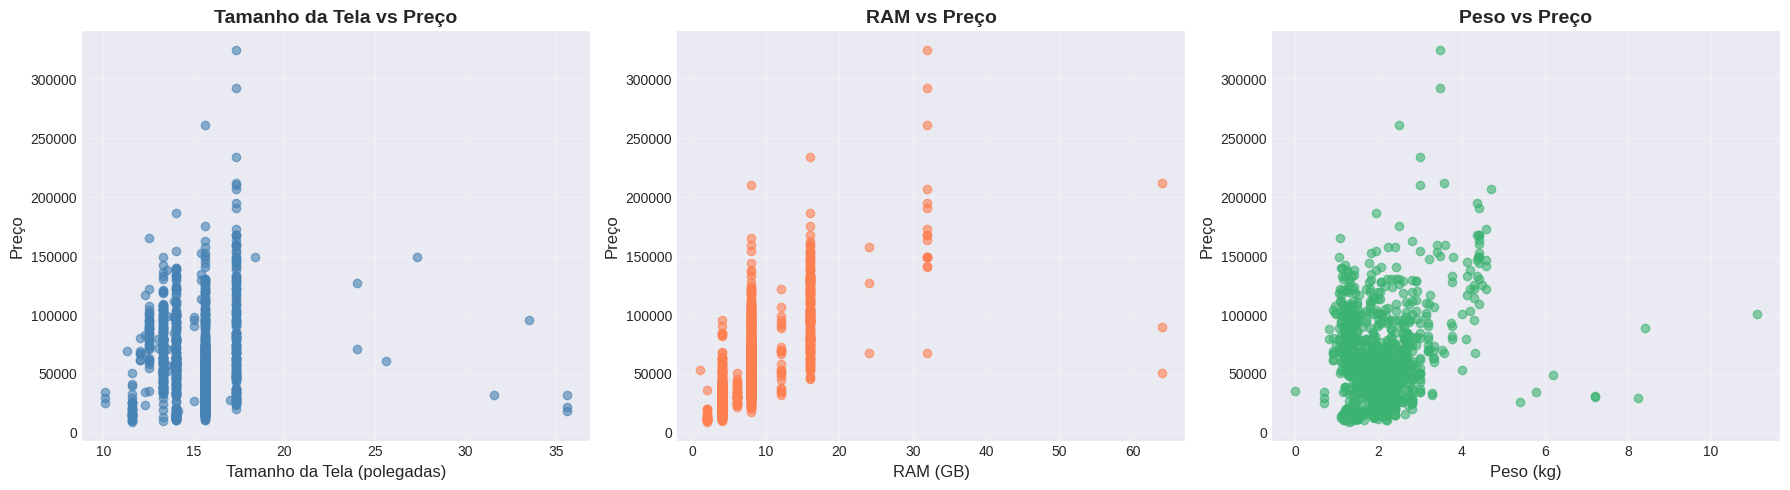

In [ ]:
# @title
# Scatter plots das variáveis numéricas vs Price
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Inches vs Price
axes[0].scatter(df_clean['Inches'], df_clean['Price'], alpha=0.6, color='steelblue')
axes[0].set_xlabel('Tamanho da Tela (polegadas)', fontsize=12)
axes[0].set_ylabel('Preço', fontsize=12)
axes[0].set_title('Tamanho da Tela vs Preço', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Ram vs Price
axes[1].scatter(df_clean['Ram'], df_clean['Price'], alpha=0.6, color='coral')
axes[1].set_xlabel('RAM (GB)', fontsize=12)
axes[1].set_ylabel('Preço', fontsize=12)
axes[1].set_title('RAM vs Preço', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Weight vs Price
axes[2].scatter(df_clean['Weight'], df_clean['Price'], alpha=0.6, color='mediumseagreen')
axes[2].set_xlabel('Peso (kg)', fontsize=12)
axes[2].set_ylabel('Preço', fontsize=12)
axes[2].set_title('Peso vs Preço', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Identificação de Outliers

Nesta seção, identificamos e quantificamos outliers nas variáveis numéricas utilizando o método IQR (Intervalo Interquartil). A visualização com boxplots nos ajuda a ter uma clara percepção de onde esses valores extremos se encontram em cada característica.

In [ ]:
# @title
# Função para identificar outliers usando IQR
def identify_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    return outliers, lower_bound, upper_bound

# Identificar outliers para cada variável numérica
print("="*80)
print("IDENTIFICAÇÃO DE OUTLIERS (MÉTODO IQR)")
print("="*80)

outlier_info = {}
for col in ["Inches", "Weight"]:
    outliers, lower, upper = identify_outliers_iqr(df_clean, col)
    outlier_info[col] = {
        'count': len(outliers),
        'percentage': (len(outliers) / len(df_clean)) * 100,
        'lower_bound': lower,
        'upper_bound': upper
    }

    print(f"\n{col}:")
    print(f"  - Outliers encontrados: {len(outliers)} ({(len(outliers)/len(df_clean)*100):.2f}%)")
    print(f"  - Limite inferior: {lower:.2f}")
    print(f"  - Limite superior: {upper:.2f}")
    if len(outliers) > 0:
        print(f"  - Valores mín/máx dos outliers: {outliers[col].min():.2f} / {outliers[col].max():.2f}")

IDENTIFICAÇÃO DE OUTLIERS (MÉTODO IQR)

Inches:
  - Outliers encontrados: 45 (3.53%)
  - Limite inferior: 11.60
  - Limite superior: 18.00
  - Valores mín/máx dos outliers: 10.10 / 35.60

Weight:
  - Outliers encontrados: 55 (4.32%)
  - Limite inferior: 0.27
  - Limite superior: 3.55
  - Valores mín/máx dos outliers: 0.00 / 11.10


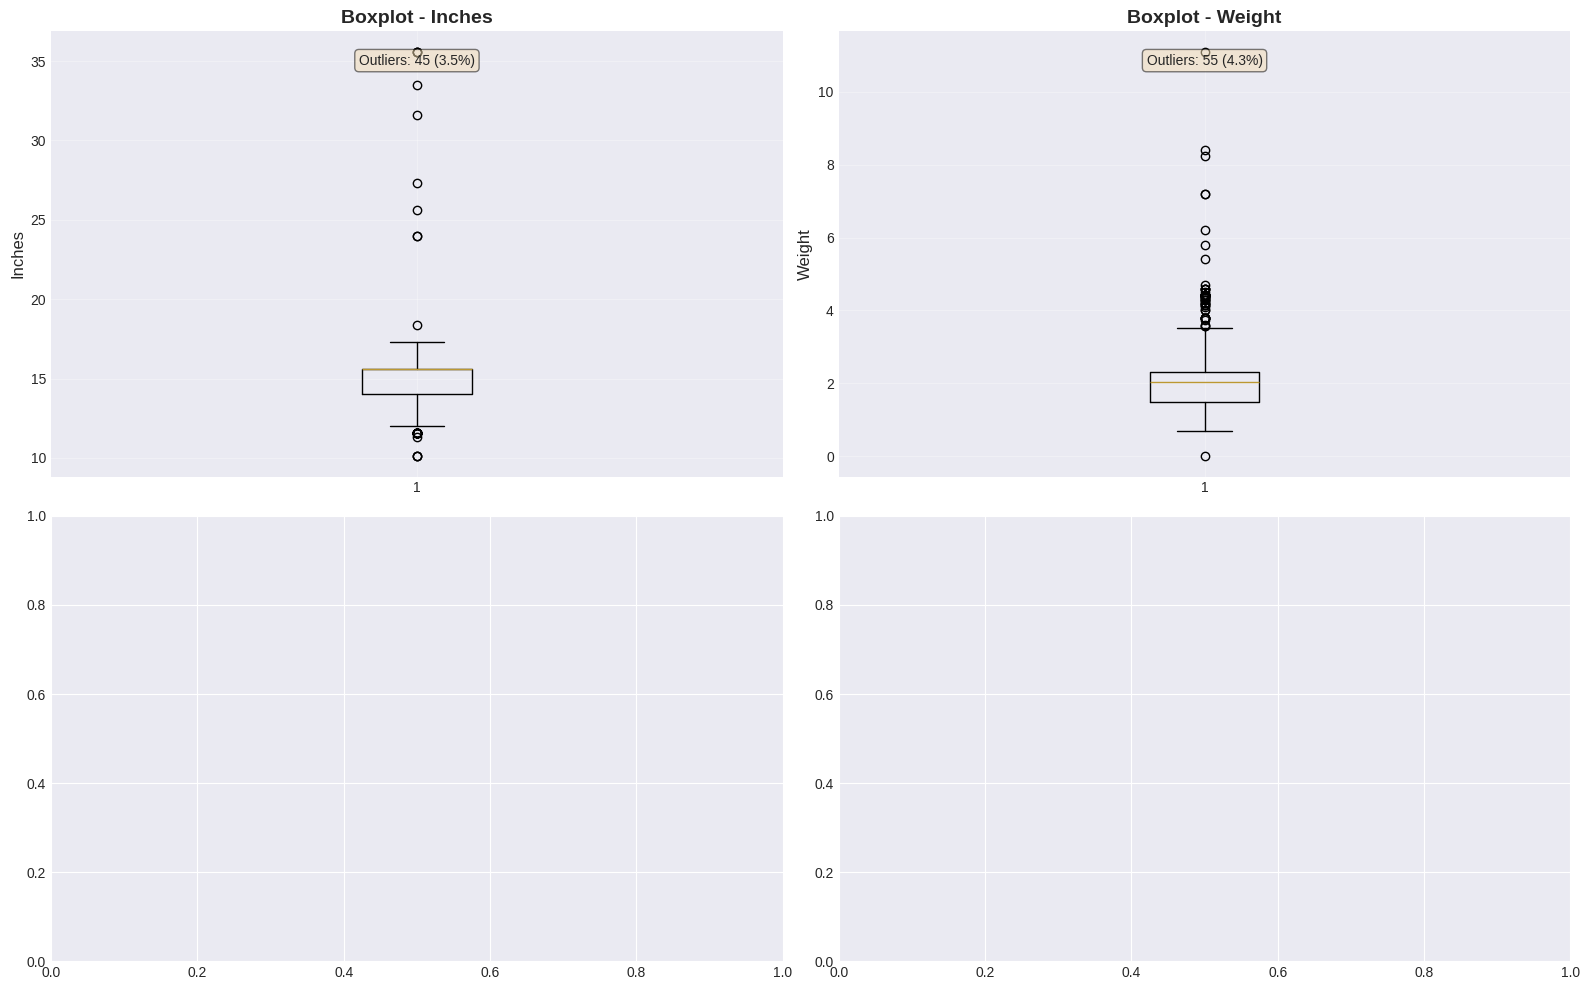

In [ ]:
# @title
# Visualização de outliers com boxplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, col in enumerate(["Inches", "Weight"]):
    row = idx // 2
    col_idx = idx % 2

    axes[row, col_idx].boxplot(df_clean[col], vert=True)
    axes[row, col_idx].set_ylabel(col, fontsize=12)
    axes[row, col_idx].set_title(f'Boxplot - {col}', fontsize=14, fontweight='bold')
    axes[row, col_idx].grid(True, alpha=0.3)

    # Adicionar informação de outliers
    outlier_count = outlier_info[col]['count']
    outlier_pct = outlier_info[col]['percentage']
    axes[row, col_idx].text(0.5, 0.95, f'Outliers: {outlier_count} ({outlier_pct:.1f}%)',
                            transform=axes[row, col_idx].transAxes,
                            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                            verticalalignment='top', horizontalalignment='center')

plt.tight_layout()
plt.show()

## 6. Tratamento de Outliers

O tratamento de outliers é realizado para mitigar seu impacto no modelo. Para as variáveis 'Inches' e 'Weight', aplicamos a técnica de `capping`, limitando os valores aos limites inferior e superior do IQR. Para 'Price' e 'Ram', decidimos manter os outliers, pois representam legitimamente a variedade de laptops no mercado.

In [ ]:
# @title
# Estratégia de tratamento de outliers
# Para Price: IGNORAR outliers (valores fazem sentido - laptops premium e básicos)
# Para Ram: IGNORAR outliers (valores fazem sentido - diferentes configurações)
# Para outras variáveis: usar capping (limitar aos limites IQR)

df_treated = df_clean.copy()
rows_before = len(df_treated)

print("="*80)
print("TRATAMENTO DE OUTLIERS")
print("="*80)

# 1. Price: IGNORAR - Manter todos os valores (laptops premium são legítimos)
print(f"\n✓ Price: Outliers mantidos (valores são legítimos)")

# 2. Ram: IGNORAR - Manter todos os valores (diferentes configurações são válidas)
print(f"✓ Ram: Outliers mantidos (valores são válidos)")

# 3. Inches: Capping nos limites IQR
inches_lower = outlier_info['Inches']['lower_bound']
inches_upper = outlier_info['Inches']['upper_bound']
df_treated['Inches'] = df_treated['Inches'].clip(lower=inches_lower, upper=inches_upper)
print(f"✓ Inches: Aplicado capping [{inches_lower:.2f}, {inches_upper:.2f}]")

# 4. Weight: Capping nos limites IQR
weight_lower = outlier_info['Weight']['lower_bound']
weight_upper = outlier_info['Weight']['upper_bound']
df_treated['Weight'] = df_treated['Weight'].clip(lower=weight_lower, upper=weight_upper)
print(f"✓ Weight: Aplicado capping [{weight_lower:.2f}, {weight_upper:.2f}]")

print(f"\nShape após tratamento: {df_treated.shape}")
print(f"Linhas removidas: {rows_before - len(df_treated)}")


TRATAMENTO DE OUTLIERS

✓ Price: Outliers mantidos (valores são legítimos)
✓ Ram: Outliers mantidos (valores são válidos)
✓ Inches: Aplicado capping [11.60, 18.00]
✓ Weight: Aplicado capping [0.27, 3.55]

Shape após tratamento: (1273, 11)
Linhas removidas: 0


## 7. Feature Engineering

O Feature Engineering é uma etapa crucial para criar novas variáveis a partir das existentes, visando melhorar a performance do modelo. Aqui, extraímos informações detalhadas sobre CPU, memória (SSD/HDD), resolução da tela (PPI, touchscreen, IPS, Retina), GPU e simplificamos o sistema operacional, adicionando novas perspectivas aos dados.

In [ ]:
# @title
# Feature Engineering
df_features = df_treated.copy()

print("="*80)
print("FEATURE ENGINEERING")
print("="*80)

# 1. Extrair informações do CPU
def extract_cpu_info(cpu):
    cpu_brand = 'Other'
    if 'Intel' in cpu:
        cpu_brand = 'Intel'
    elif 'AMD' in cpu:
        cpu_brand = 'AMD'
    elif 'Samsung' in cpu:
        cpu_brand = 'Samsung'
    else:
        cpu_brand = 'Other'

    # Extrair velocidade (GHz)
    speed_match = re.search(r'(\d+\.?\d*)GHz', cpu)
    cpu_speed = float(speed_match.group(1)) if speed_match else 0

    return cpu_brand, cpu_speed

df_features['Cpu_Brand'] = df_features['Cpu'].apply(lambda x: extract_cpu_info(x)[0])
df_features['Cpu_Speed'] = df_features['Cpu'].apply(lambda x: extract_cpu_info(x)[1])

print("✓ CPU: Extraído marca e velocidade")

# 2. Extrair informações de Memory (SSD/HDD)
def extract_memory_info(memory):
    ssd_gb = 0
    hdd_gb = 0

    # Procurar por SSD
    ssd_match = re.findall(r'(\d+)GB\s*SSD', memory)
    if ssd_match:
        ssd_gb = sum([int(x) for x in ssd_match])

    ssd_tb_match = re.findall(r'(\d+)TB\s*SSD', memory)
    if ssd_tb_match:
        ssd_gb += sum([int(x) * 1024 for x in ssd_tb_match])

    # Procurar por HDD
    hdd_match = re.findall(r'(\d+)GB\s*HDD', memory)
    if hdd_match:
        hdd_gb = sum([int(x) for x in hdd_match])

    hdd_tb_match = re.findall(r'(\d+)TB\s*HDD', memory)
    if hdd_tb_match:
        hdd_gb += sum([int(x) * 1024 for x in hdd_tb_match])

    # Flash Storage
    flash_match = re.findall(r'(\d+)GB\s*Flash', memory)
    if flash_match:
        ssd_gb += sum([int(x) for x in flash_match])

    return ssd_gb, hdd_gb

df_features['SSD_GB'] = df_features['Memory'].apply(lambda x: extract_memory_info(x)[0])
df_features['HDD_GB'] = df_features['Memory'].apply(lambda x: extract_memory_info(x)[1])
df_features['Total_Storage'] = df_features['SSD_GB'] + df_features['HDD_GB']

print("✓ Memory: Extraído SSD, HDD e storage total")

# 3. Extrair resolução da tela
def extract_resolution(screen):
    # Extrair resolução numérica
    res_match = re.search(r'(\d+)x(\d+)', screen)
    if res_match:
        width = int(res_match.group(1))
        height = int(res_match.group(2))
        pixels = width * height
    else:
        pixels = 0

    # Identificar se é touchscreen
    is_touchscreen = 1 if 'Touchscreen' in screen else 0

    # Identificar se é IPS
    is_ips = 1 if 'IPS' in screen else 0

    # Identificar se é Retina
    is_retina = 1 if 'Retina' in screen else 0

    return pixels, is_touchscreen, is_ips, is_retina

df_features['Screen_Pixels'] = df_features['ScreenResolution'].apply(lambda x: extract_resolution(x)[0])
df_features['Is_Touchscreen'] = df_features['ScreenResolution'].apply(lambda x: extract_resolution(x)[1])
df_features['Is_IPS'] = df_features['ScreenResolution'].apply(lambda x: extract_resolution(x)[2])
df_features['Is_Retina'] = df_features['ScreenResolution'].apply(lambda x: extract_resolution(x)[3])

# PPI (Pixels per Inch)
df_features['PPI'] = np.sqrt(df_features['Screen_Pixels']) / df_features['Inches']

print("✓ ScreenResolution: Extraído pixels, touchscreen, IPS, Retina e PPI")

# 4. Extrair informações da GPU
def extract_gpu_info(gpu):
    if 'Intel' in gpu:
        return 'Intel', '0'
    elif 'AMD' in gpu or 'Radeon' in gpu:
        if 'R2' in gpu or 'R3' in gpu or 'R4' in gpu or 'R5' in gpu or 'R7' in gpu or 'R9' in gpu:
            return 'AMD', '0'
        return 'AMD', '1'
    elif 'Nvidia' in gpu or 'GeForce' in gpu:
        return 'Nvidia', '1'
    else:
        return 'Other', '0'

df_features['Gpu_Brand'] = df_features['Gpu'].apply(lambda x: extract_gpu_info(x)[0])
df_features['Gpu_Dedicated'] = df_features['Gpu'].apply(lambda x: extract_gpu_info(x)[1])

print("✓ GPU: Extraído marca da GPU")

# 5. Simplificar OpSys
def simplify_opsys(opsys):
    if 'Windows' in opsys:
        return 'Windows'
    elif 'Mac' in opsys or 'macOS' in opsys:
        return 'macOS'
    elif 'Linux' in opsys:
        return 'Linux'
    else:
        return 'No OS'

df_features['OpSys_Simple'] = df_features['OpSys'].apply(simplify_opsys)

print("✓ OpSys: Simplificado")

print(f"\nTotal de features após engenharia: {df_features.shape[1]}")
print(f"\nNovas features criadas:")
new_features = ['Cpu_Brand', 'Cpu_Speed', 'SSD_GB', 'HDD_GB', 'Total_Storage',
                'Screen_Pixels', 'Is_Touchscreen', 'Is_IPS', 'Is_Retina', 'PPI',
                'Gpu_Brand', 'Gpu_Dedicated', 'OpSys_Simple']
for feat in new_features:
    print(f"  - {feat}")


FEATURE ENGINEERING
✓ CPU: Extraído marca e velocidade
✓ Memory: Extraído SSD, HDD e storage total
✓ ScreenResolution: Extraído pixels, touchscreen, IPS, Retina e PPI
✓ GPU: Extraído marca da GPU
✓ OpSys: Simplificado

Total de features após engenharia: 24

Novas features criadas:
  - Cpu_Brand
  - Cpu_Speed
  - SSD_GB
  - HDD_GB
  - Total_Storage
  - Screen_Pixels
  - Is_Touchscreen
  - Is_IPS
  - Is_Retina
  - PPI
  - Gpu_Brand
  - Gpu_Dedicated
  - OpSys_Simple


In [ ]:
# @title
# Verificar as novas features
df_features[new_features + ['Price']].head(10)

,Cpu_Brand,Cpu_Speed,SSD_GB,HDD_GB,Total_Storage,Screen_Pixels,Is_Touchscreen,Is_IPS,Is_Retina,PPI,Gpu_Brand,Gpu_Dedicated,OpSys_Simple,Price
0,Intel,2.3,128,0,128,4096000,0,1,1,152.169752,Intel,0,macOS,71378.6832
1,Intel,1.8,128,0,128,1296000,0,0,0,85.595486,Intel,0,macOS,47895.5232
2,Intel,2.5,256,0,256,2073600,0,0,0,92.307692,Intel,0,No OS,30636.0000
3,Intel,2.7,512,0,512,5184000,0,1,1,147.846748,AMD,1,macOS,135195.3360
4,Intel,3.1,256,0,256,4096000,0,1,1,152.169752,Intel,0,macOS,96095.8080
5,AMD,3.0,0,500,500,1049088,0,0,0,65.657049,AMD,0,Windows,21312.0000
6,Intel,2.2,256,0,256,5184000,0,1,1,147.846748,Intel,0,macOS,114017.6016
7,Intel,1.8,256,0,256,1296000,0,0,0,85.595486,Intel,0,macOS,61735.5360
8,Intel,1.8,512,0,512,2073600,0,0,0,102.857143,Nvidia,1,Windows,79653.6000
9,Intel,1.6,256,0,256,2073600,0,1,0,102.857143,Intel,0,Windows,41025.6000


## 7.1 Feature Engineering Avançado - Interações entre Features

Vamos criar features de interação para capturar relações não-lineares complexas entre variáveis.

In [ ]:
# @title
# Feature Engineering Avançado - Criar Interações
print("="*80)
print("FEATURE ENGINEERING AVANÇADO - INTERAÇÕES ENTRE FEATURES")
print("="*80)

df_interactions = df_features.copy()

# 1. Interações multiplicativas (capturar efeitos combinados)
print("\n✓ Criando features de interação multiplicativa...")

# RAM × CPU Speed (Laptops com muita RAM e CPU rápida são premium)
df_interactions['RAM_x_CPU_Speed'] = df_interactions['Ram'] * df_interactions['Cpu_Speed']

# RAM × SSD (Configuração ideal para performance)
df_interactions['RAM_x_SSD'] = df_interactions['Ram'] * df_interactions['SSD_GB']

# Screen Pixels × PPI (Qualidade total da tela)
df_interactions['Pixels_x_PPI'] = df_interactions['Screen_Pixels'] * df_interactions['PPI']

# Total Storage × RAM (Capacidade total do sistema)
df_interactions['Storage_x_RAM'] = df_interactions['Total_Storage'] * df_interactions['Ram']

# SSD × CPU Speed (Performance geral do sistema)
df_interactions['SSD_x_CPU_Speed'] = df_interactions['SSD_GB'] * df_interactions['Cpu_Speed']

# Inches × Screen Pixels (Tamanho e resolução combinados)
df_interactions['Inches_x_Pixels'] = df_interactions['Inches'] * df_interactions['Screen_Pixels']

print(f"   - RAM × CPU_Speed")
print(f"   - RAM × SSD")
print(f"   - Screen_Pixels × PPI")
print(f"   - Total_Storage × RAM")
print(f"   - SSD × CPU_Speed")
print(f"   - Inches × Screen_Pixels")

# 2. Razões (capturar proporções importantes)
print("\n✓ Criando features de razão...")

# Razão SSD/Total Storage (quanto do storage é SSD)
df_interactions['SSD_Ratio'] = df_interactions['SSD_GB'] / (df_interactions['Total_Storage'] + 1)  # +1 para evitar divisão por zero

# Pixels por polegada ao quadrado (densidade de pixels normalizada)
df_interactions['Pixels_per_Inch_Squared'] = df_interactions['Screen_Pixels'] / (df_interactions['Inches'] ** 2 + 1)

# RAM por GHz de CPU (balanceamento RAM/CPU)
df_interactions['RAM_per_GHz'] = df_interactions['Ram'] / (df_interactions['Cpu_Speed'] + 0.1)

print(f"   - SSD_Ratio (SSD/Total_Storage)")
print(f"   - Pixels_per_Inch_Squared")
print(f"   - RAM_per_GHz")

# 3. Features polinomiais para as mais importantes (capturar não-linearidade)
print("\n✓ Criando features polinomiais...")

# RAM ao quadrado (relação não-linear com preço)
df_interactions['RAM_squared'] = df_interactions['Ram'] ** 2

# SSD ao quadrado
df_interactions['SSD_squared'] = df_interactions['SSD_GB'] ** 2

# CPU Speed ao quadrado
df_interactions['CPU_Speed_squared'] = df_interactions['Cpu_Speed'] ** 2

print(f"   - RAM²")
print(f"   - SSD²")
print(f"   - CPU_Speed²")

# 4. Features de "premium-ness" (indicadores de laptop premium)
print("\n✓ Criando indicadores de características premium...")

# High-end configuration (RAM alta + SSD grande + CPU rápida)
df_interactions['Premium_Config'] = (
    (df_interactions['Ram'] >= 16).astype(int) +
    (df_interactions['SSD_GB'] >= 512).astype(int) +
    (df_interactions['Cpu_Speed'] >= 2.5).astype(int) +
    (df_interactions['Is_IPS'] == 1).astype(int)
)

# Ultra-portable (leve + tela pequena + SSD)
df_interactions['Ultraportable'] = (
    (df_interactions['Weight'] <= 1.5).astype(int) *
    (df_interactions['Inches'] <= 14).astype(int) *
    (df_interactions['SSD_GB'] > 0).astype(int)
)

# Gaming/Workstation indicator
df_interactions['Gaming_Workstation'] = (
    (df_interactions['Ram'] >= 16).astype(int) *
    (df_interactions['Gpu_Dedicated'] == '1').astype(int) *
    (df_interactions['SSD_GB'] >= 256).astype(int)
)

print(f"   - Premium_Config (combinação de features premium)")
print(f"   - Ultraportable (leve + compacto + SSD)")
print(f"   - Gaming_Workstation (RAM alta + GPU dedicada + SSD grande)")

# Listar todas as novas features criadas
new_interaction_features = [
    'RAM_x_CPU_Speed', 'RAM_x_SSD', 'Pixels_x_PPI', 'Storage_x_RAM',
    'SSD_x_CPU_Speed', 'Inches_x_Pixels', 'SSD_Ratio', 'Pixels_per_Inch_Squared',
    'RAM_per_GHz', 'RAM_squared', 'SSD_squared', 'CPU_Speed_squared',
    'Premium_Config', 'Ultraportable', 'Gaming_Workstation'
]

print("\n" + "="*80)
print("RESUMO")
print("="*80)
print(f"Total de features antes: {df_features.shape[1]}")
print(f"Total de features após interações: {df_interactions.shape[1]}")
print(f"Novas features criadas: {len(new_interaction_features)}")

print("\n💡 Tipos de features criadas:")
print(f"   - Interações multiplicativas: 6")
print(f"   - Razões/Proporções: 3")
print(f"   - Polinomiais (quadráticas): 3")
print(f"   - Indicadores premium: 3")

# Verificar algumas estatísticas das novas features
print("\n📊 Exemplos de valores das novas features:")
print(df_interactions[new_interaction_features].describe().T[['mean', 'std', 'min', 'max']].head(10))

FEATURE ENGINEERING AVANÇADO - INTERAÇÕES ENTRE FEATURES

✓ Criando features de interação multiplicativa...
   - RAM × CPU_Speed
   - RAM × SSD
   - Screen_Pixels × PPI
   - Total_Storage × RAM
   - SSD × CPU_Speed
   - Inches × Screen_Pixels

✓ Criando features de razão...
   - SSD_Ratio (SSD/Total_Storage)
   - Pixels_per_Inch_Squared
   - RAM_per_GHz

✓ Criando features polinomiais...
   - RAM²
   - SSD²
   - CPU_Speed²

✓ Criando indicadores de características premium...
   - Premium_Config (combinação de features premium)
   - Ultraportable (leve + compacto + SSD)
   - Gaming_Workstation (RAM alta + GPU dedicada + SSD grande)

RESUMO
Total de features antes: 24
Total de features após interações: 39
Novas features criadas: 15

💡 Tipos de features criadas:
   - Interações multiplicativas: 6
   - Razões/Proporções: 3
   - Polinomiais (quadráticas): 3
   - Indicadores premium: 3

📊 Exemplos de valores das novas features:
                                 mean           std           mi

## 7.2 Remoção de Outliers Extremos (Preço > 200k)

Laptops extremamente caros podem estar distorcendo o modelo. Vamos removê-los para melhorar a performance geral.

REMOÇÃO DE OUTLIERS EXTREMOS - LAPTOPS > 200K

📊 ANTES DA REMOÇÃO:
Total de registros: 1273
Preço máximo: INR 324,954.72
Preço médio: INR 59,955.81
Preço mediano: INR 52,161.12

⚠️ Laptops com preço > INR 200,000: 7 (0.55%)

🔍 Detalhes dos laptops extremamente caros:
     Company     TypeName  Ram       Price
196    Razer       Gaming   32  324954.720
830    Razer       Gaming   32  292986.720
610   Lenovo     Notebook   32  261018.720
749       HP  Workstation   16  233845.920
1066    Asus       Gaming   64  211788.000
1136      HP  Workstation    8  210424.032
238     Asus       Gaming   32  207259.200


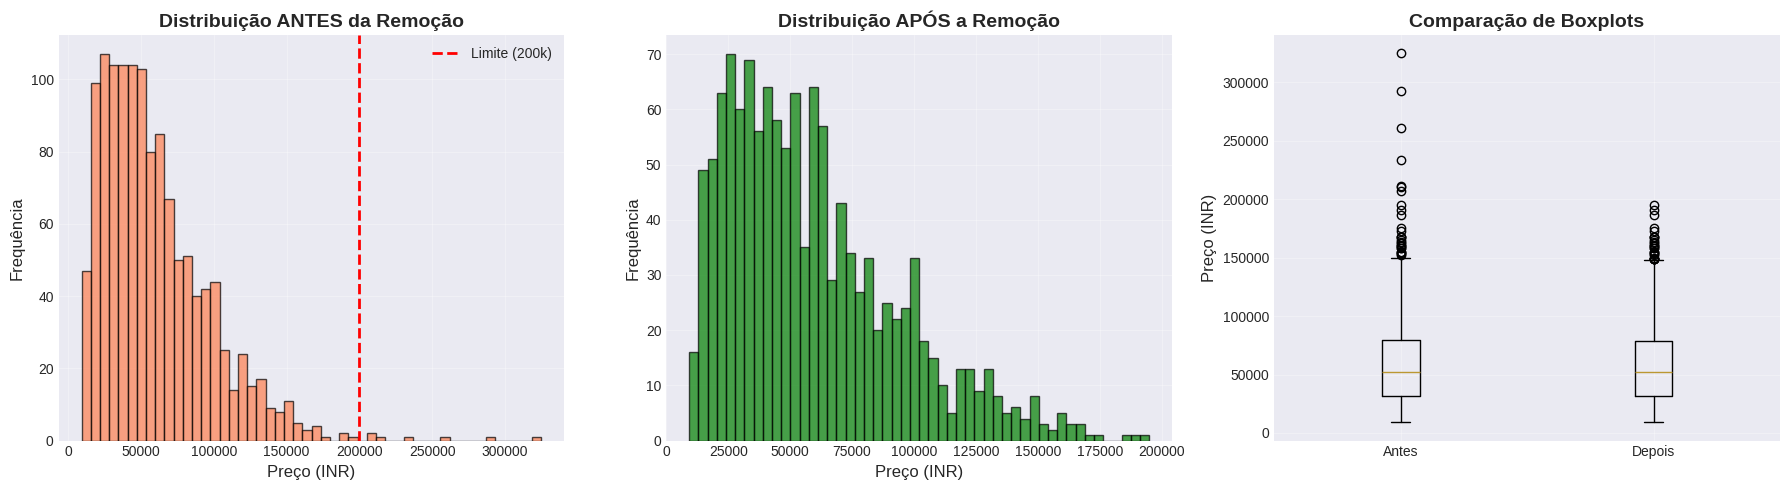


📊 APÓS A REMOÇÃO:
Total de registros: 1266
Registros removidos: 7
Percentual removido: 0.55%

Preço máximo: INR 194,972.83
Preço médio: INR 58,911.12
Preço mediano: INR 51,948.00
Desvio padrão: INR 34,536.08

📈 IMPACTO DA REMOÇÃO:
Mudança na média: -1.74%
Mudança no desvio padrão: -7.49%

✅ Dataset sem outliers extremos pronto para modelagem!

🔗 CORRELAÇÃO COM FEATURES PRINCIPAIS (Antes vs Depois)
Ram                 : 0.6856 → 0.6684 (Δ -0.0172)
SSD_GB              : 0.6693 → 0.6615 (Δ -0.0078)
Cpu_Speed           : 0.4290 → 0.4322 (Δ +0.0032)
Screen_Pixels       : 0.5167 → 0.5021 (Δ -0.0146)


In [ ]:
# @title
# Remover Outliers Extremos - Laptops > 200k
print("="*80)
print("REMOÇÃO DE OUTLIERS EXTREMOS - LAPTOPS > 200K")
print("="*80)

# Análise antes da remoção
print("\n📊 ANTES DA REMOÇÃO:")
print(f"Total de registros: {len(df_interactions)}")
print(f"Preço máximo: INR {df_interactions['Price'].max():,.2f}")
print(f"Preço médio: INR {df_interactions['Price'].mean():,.2f}")
print(f"Preço mediano: INR {df_interactions['Price'].median():,.2f}")

# Identificar laptops extremamente caros
extreme_outliers = df_interactions[df_interactions['Price'] > 200000]
print(f"\n⚠️ Laptops com preço > INR 200,000: {len(extreme_outliers)} ({len(extreme_outliers)/len(df_interactions)*100:.2f}%)")

if len(extreme_outliers) > 0:
    print("\n🔍 Detalhes dos laptops extremamente caros:")
    print(extreme_outliers[['Company', 'TypeName', 'Ram', 'Price']].sort_values('Price', ascending=False))

# Visualizar distribuição antes e depois
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Antes da remoção
axes[0].hist(df_interactions['Price'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0].axvline(x=200000, color='red', linestyle='--', linewidth=2, label='Limite (200k)')
axes[0].set_xlabel('Preço (INR)', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)
axes[0].set_title('Distribuição ANTES da Remoção', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Remover outliers extremos
df_no_extreme = df_interactions[df_interactions['Price'] <= 200000].copy()

# Após remoção
axes[1].hist(df_no_extreme['Price'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Preço (INR)', fontsize=12)
axes[1].set_ylabel('Frequência', fontsize=12)
axes[1].set_title('Distribuição APÓS a Remoção', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Boxplot comparativo
data_to_plot = [df_interactions['Price'], df_no_extreme['Price']]
axes[2].boxplot(data_to_plot, labels=['Antes', 'Depois'], vert=True)
axes[2].set_ylabel('Preço (INR)', fontsize=12)
axes[2].set_title('Comparação de Boxplots', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas após remoção
print("\n" + "="*80)
print("📊 APÓS A REMOÇÃO:")
print("="*80)
print(f"Total de registros: {len(df_no_extreme)}")
print(f"Registros removidos: {len(df_interactions) - len(df_no_extreme)}")
print(f"Percentual removido: {(len(df_interactions) - len(df_no_extreme))/len(df_interactions)*100:.2f}%")
print(f"\nPreço máximo: INR {df_no_extreme['Price'].max():,.2f}")
print(f"Preço médio: INR {df_no_extreme['Price'].mean():,.2f}")
print(f"Preço mediano: INR {df_no_extreme['Price'].median():,.2f}")
print(f"Desvio padrão: INR {df_no_extreme['Price'].std():,.2f}")

# Calcular mudanças
mean_change = ((df_no_extreme['Price'].mean() - df_interactions['Price'].mean()) /
               df_interactions['Price'].mean() * 100)
std_change = ((df_no_extreme['Price'].std() - df_interactions['Price'].std()) /
              df_interactions['Price'].std() * 100)

print("\n📈 IMPACTO DA REMOÇÃO:")
print(f"Mudança na média: {mean_change:.2f}%")
print(f"Mudança no desvio padrão: {std_change:.2f}%")

print("\n✅ Dataset sem outliers extremos pronto para modelagem!")

# Verificar correlação antes e depois
print("\n" + "="*80)
print("🔗 CORRELAÇÃO COM FEATURES PRINCIPAIS (Antes vs Depois)")
print("="*80)
key_features = ['Ram', 'SSD_GB', 'Cpu_Speed', 'Screen_Pixels']
for feature in key_features:
    corr_before = df_interactions[[feature, 'Price']].corr().iloc[0, 1]
    corr_after = df_no_extreme[[feature, 'Price']].corr().iloc[0, 1]
    change = corr_after - corr_before
    print(f"{feature:20s}: {corr_before:.4f} → {corr_after:.4f} (Δ {change:+.4f})")

## 8. Seleção de Feature e Preparação para a Modelagem

### 📊 Resumo das Melhorias Aplicadas

Antes de prosseguir com a modelagem, vamos resumir as melhorias implementadas:

1. **Feature Engineering Avançado** (Seção 7.1):
   - ✅ 15 novas features de interação
   - ✅ Interações multiplicativas (RAM×CPU_Speed, etc.)
   - ✅ Features polinomiais e indicadores premium

2. **Remoção de Outliers Extremos** (Seção 7.2):
   - ✅ Laptops > 200k INR removidos
   - ✅ Dataset mais homogêneo para treinamento

3. **Preparação para Nova Modelagem**:
   - ✅ 32 features totais (17 originais + 15 interações)
   - ✅ Dataset limpo: `df_no_extreme`

In [ ]:
# @title
# ⚠️ IMPORTANTE: Usar df_no_extreme (sem outliers > 200k) com features de interação
print("="*80)
print("PREPARAÇÃO DOS DADOS - COM FEATURES DE INTERAÇÃO E SEM OUTLIERS")
print("="*80)

# Selecionar features para o modelo (incluindo novas interações)
features_to_use = [
    # Originais numéricas
    'Inches', 'Ram', 'Weight',
    # Engenharia - CPU
    'Cpu_Speed',
    # Engenharia - GPU
    'Gpu_Dedicated',
    # Engenharia - Storage
    'SSD_GB', 'HDD_GB', 'Total_Storage',
    # Engenharia - Screen
    'Screen_Pixels', 'Is_Touchscreen', 'Is_IPS', 'Is_Retina',
    # Categóricas (serão encodadas)
    'Company', 'TypeName', 'Cpu_Brand', 'Gpu_Brand', 'OpSys_Simple',
    # ✨ NOVAS FEATURES DE INTERAÇÃO
    'RAM_x_CPU_Speed', 'RAM_x_SSD', 'Pixels_x_PPI', 'Storage_x_RAM',
    'SSD_x_CPU_Speed', 'Inches_x_Pixels',
    'SSD_Ratio', 'Pixels_per_Inch_Squared', 'RAM_per_GHz',
    'RAM_squared', 'SSD_squared', 'CPU_Speed_squared',
    'Premium_Config', 'Ultraportable', 'Gaming_Workstation'
]

print(f"\n✅ Dataset usado: df_no_extreme (sem outliers > 200k)")
print(f"📊 Total de features: {len(features_to_use)} (17 originais + 15 interações)")

# Preparar dataset para modelagem
df_model = df_no_extreme[features_to_use + ['Price']].copy()

# Encoder para variáveis categóricas
categorical_features = ['Company', 'TypeName', 'Cpu_Brand', 'Gpu_Brand', 'OpSys_Simple']

print("\n" + "="*80)
print("ENCODING DE VARIÁVEIS CATEGÓRICAS")
print("="*80)

# Label Encoding
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le
    print(f"✓ {col}: {len(le.classes_)} classes")

print(f"\n📦 Shape do dataset para modelagem: {df_model.shape}")
print(f"🎯 Features selecionadas: {len(features_to_use)}")

# Verificar correlações com as novas features
correlation_with_price = df_model.corr()['Price'].sort_values(ascending=False)
print("\n" + "="*80)
print("🔝 TOP 20 CORRELAÇÕES COM PRICE (incluindo novas features)")
print("="*80)
print(correlation_with_price.head(20))


PREPARAÇÃO DOS DADOS - COM FEATURES DE INTERAÇÃO E SEM OUTLIERS

✅ Dataset usado: df_no_extreme (sem outliers > 200k)
📊 Total de features: 32 (17 originais + 15 interações)

ENCODING DE VARIÁVEIS CATEGÓRICAS
✓ Company: 19 classes
✓ TypeName: 6 classes
✓ Cpu_Brand: 3 classes
✓ Gpu_Brand: 4 classes
✓ OpSys_Simple: 4 classes

📦 Shape do dataset para modelagem: (1266, 33)
🎯 Features selecionadas: 32

🔝 TOP 20 CORRELAÇÕES COM PRICE (incluindo novas features)
Price                      1.000000
RAM_x_CPU_Speed            0.703906
SSD_x_CPU_Speed            0.693636
Premium_Config             0.676324
Ram                        0.668431
SSD_GB                     0.661475
RAM_x_SSD                  0.652433
SSD_squared                0.529863
RAM_per_GHz                0.517984
Inches_x_Pixels            0.515333
Gaming_Workstation         0.505989
Screen_Pixels              0.502098
Storage_x_RAM              0.478599
CPU_Speed_squared          0.445323
Pixels_per_Inch_Squared    0.440028
Pi

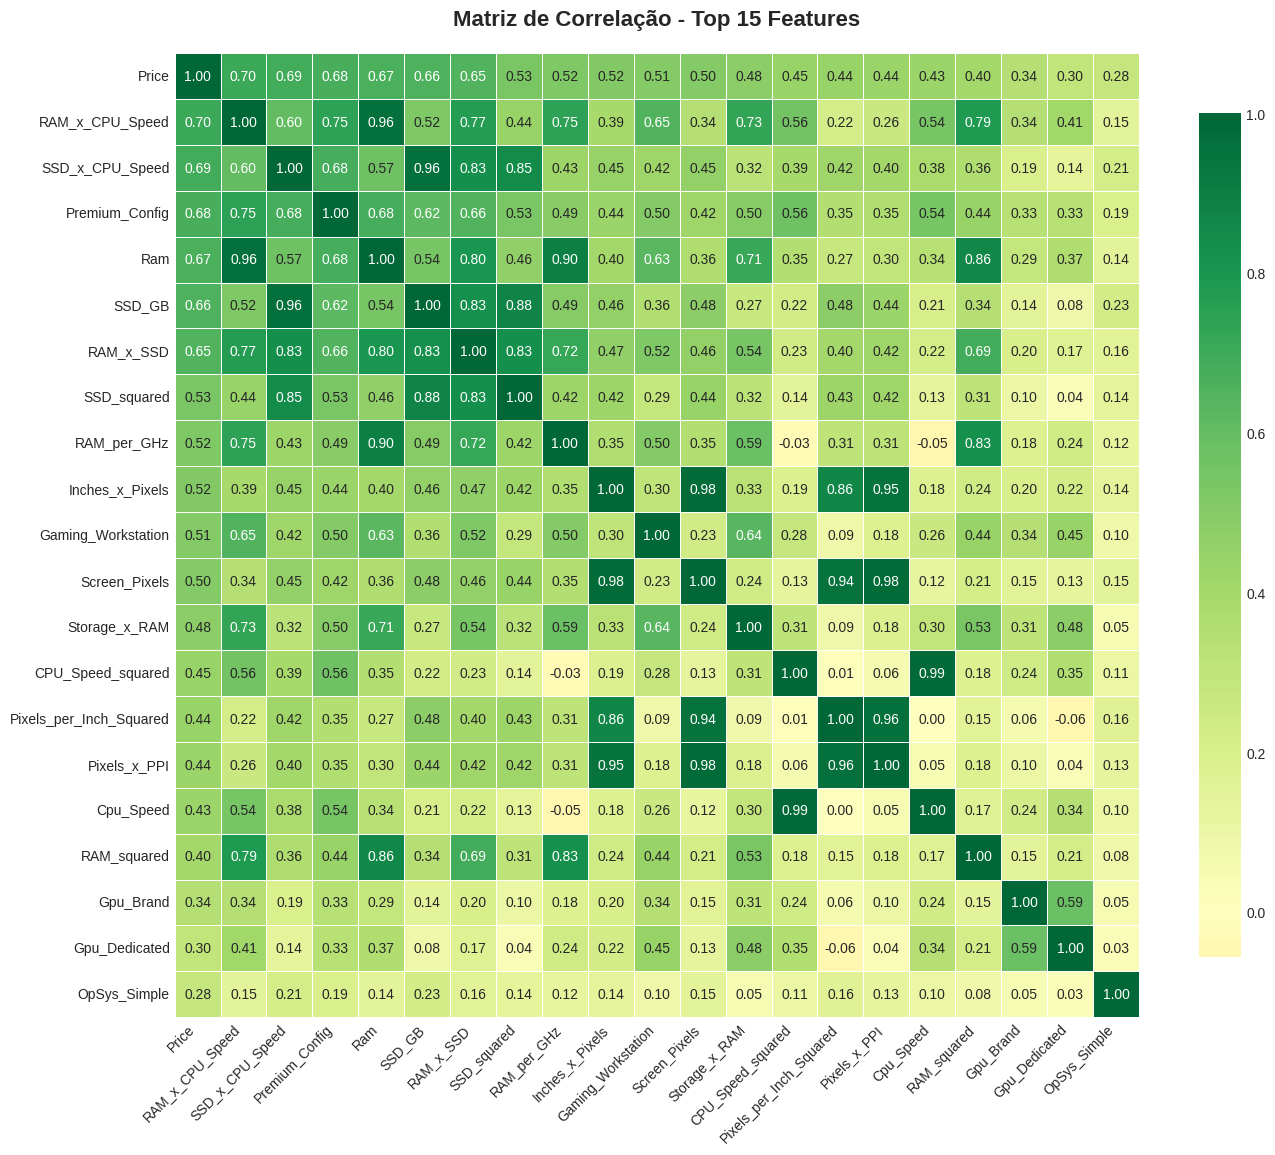

In [ ]:
# @title
# Visualizar matriz de correlação das top features (incluindo novas interações)
top_features = correlation_with_price.head(21).index.tolist()  # Top 20 + Price
correlation_matrix_top = df_model[top_features].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix_top, annot=True, cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, fmt='.2f', cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Top 15 Features', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Treino da Baseline (Linear Regression)

Antes de treinar modelos mais complexos, estabelecemos uma baseline utilizando a Regressão Linear. Esta etapa é fundamental para ter um ponto de comparação para a performance dos modelos mais avançados, permitindo avaliar a eficácia das melhorias posteriores. Também dividimos os dados em conjuntos de treino e teste e os normalizamos.

In [ ]:
# @title
# Preparar dados para modelagem
X = df_model.drop('Price', axis=1)
y = df_model['Price']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("="*80)
print("PREPARAÇÃO DOS DADOS")
print("="*80)
print(f"Total de amostras: {len(df_model)}")
print(f"Training set: {len(X_train)} amostras ({len(X_train)/len(df_model)*100:.1f}%)")
print(f"Test set: {len(X_test)} amostras ({len(X_test)/len(df_model)*100:.1f}%)")
print(f"Número de features: {X_train.shape[1]}")

# Normalizar os dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Dados normalizados com StandardScaler")

PREPARAÇÃO DOS DADOS
Total de amostras: 1266
Training set: 1012 amostras (79.9%)
Test set: 254 amostras (20.1%)
Número de features: 32

✓ Dados normalizados com StandardScaler


In [ ]:
# @title
# Treinar modelo baseline - Linear Regression
print("\n" + "="*80)
print("TREINANDO MODELO BASELINE - LINEAR REGRESSION")
print("="*80)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predições
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

# Métricas
train_mae_lr = mean_absolute_error(y_train, y_train_pred_lr)
test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)
train_rmse_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
test_rmse_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)

print("\n📊 MÉTRICAS DO MODELO BASELINE (Linear Regression):")
print(f"\nTreino:")
print(f"  MAE:  {train_mae_lr:.2f}")
print(f"  RMSE: {train_rmse_lr:.2f}")
print(f"  R²:   {train_r2_lr:.4f}")

print(f"\nTeste:")
print(f"  MAE:  {test_mae_lr:.2f} {'✓ OBJETIVO ATINGIDO!' if test_mae_lr < 7500 else '✗ Acima do objetivo (7500)'}")
print(f"  RMSE: {test_rmse_lr:.2f}")
print(f"  R²:   {test_r2_lr:.4f}")

# Cross-validation
cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5,
                            scoring='neg_mean_absolute_error')
cv_mae = -cv_scores.mean()
print(f"\n5-Fold CV MAE: {cv_mae:.2f} (±{cv_scores.std():.2f})")


TREINANDO MODELO BASELINE - LINEAR REGRESSION

📊 MÉTRICAS DO MODELO BASELINE (Linear Regression):

Treino:
  MAE:  13043.28
  RMSE: 17380.47
  R²:   0.7404

Teste:
  MAE:  12415.09 ✗ Acima do objetivo (7500)
  RMSE: 17104.27
  R²:   0.7748

5-Fold CV MAE: 13708.77 (±744.27)


## 10. Modelagem Avançada

Nesta seção, vamos além dos modelos baseline e testar algoritmos mais avançados para reduzir o MAE.

### 10.1 Random Forest Inicial

Antes de treinar modelos mais complexos, estabelecemos uma baseline utilizando a Regressão Linear. Esta etapa é fundamental para ter um ponto de comparação para a performance dos modelos mais avançados, permitindo avaliar a eficácia das melhorias posteriores. Também dividimos os dados em conjuntos de treino e teste e os normalizamos.

In [ ]:
# @title
# Treinar Random Forest inicial
print("="*80)
print("TREINANDO RANDOM FOREST - VERSÃO INICIAL")
print("="*80)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predições
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Métricas
train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)

print("\n📊 MÉTRICAS DO RANDOM FOREST (Inicial):")
print(f"\nTreino:")
print(f"  MAE:  {train_mae_rf:.2f}")
print(f"  RMSE: {train_rmse_rf:.2f}")
print(f"  R²:   {train_r2_rf:.4f}")

print(f"\nTeste:")
print(f"  MAE:  {test_mae_rf:.2f} {'✓ OBJETIVO ATINGIDO!' if test_mae_rf < 7500 else '✗ Acima do objetivo (7500)'}")
print(f"  RMSE: {test_rmse_rf:.2f}")
print(f"  R²:   {test_r2_rf:.4f}")

# Cross-validation
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5,
                                scoring='neg_mean_absolute_error')
cv_mae_rf = -cv_scores_rf.mean()
print(f"\n5-Fold CV MAE: {cv_mae_rf:.2f} (±{cv_scores_rf.std():.2f})")

TREINANDO RANDOM FOREST - VERSÃO INICIAL

📊 MÉTRICAS DO RANDOM FOREST (Inicial):

Treino:
  MAE:  3955.04
  RMSE: 5910.74
  R²:   0.9700

Teste:
  MAE:  8426.23 ✗ Acima do objetivo (7500)
  RMSE: 13775.99
  R²:   0.8539

5-Fold CV MAE: 10545.68 (±311.84)


### 10.2 Otimização de Hiperparâmetros

Realizamos a otimização dos hiperparâmetros do Random Forest utilizando RandomizedSearchCV. Esta técnica explora eficientemente o espaço de parâmetros, buscando a combinação que oferece o melhor desempenho (menor MAE), o que é vital para refinar a precisão do modelo.

In [ ]:
# @title
# Otimização de Hiperparâmetros do Random Forest
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

print("="*80)
print("OTIMIZAÇÃO DE HIPERPARÂMETROS - RANDOM FOREST")
print("="*80)

# Definir grid de hiperparâmetros
param_distributions = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [10, 15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# RandomizedSearchCV (mais rápido que GridSearchCV)
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=50,  # 50 combinações aleatórias
    cv=5,
    scoring='neg_mean_absolute_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("\n🔍 Buscando melhores hiperparâmetros (isso pode levar alguns minutos)...\n")
rf_random_search.fit(X_train, y_train)

# Melhores parâmetros
print("\n" + "="*80)
print("MELHORES HIPERPARÂMETROS ENCONTRADOS")
print("="*80)
best_params = rf_random_search.best_params_
for param, value in best_params.items():
    print(f"  {param}: {value}")

# Modelo otimizado
rf_best_model = rf_random_search.best_estimator_

# Predições
y_train_pred_rf_opt = rf_best_model.predict(X_train)
y_test_pred_rf_opt = rf_best_model.predict(X_test)

# Métricas
train_mae_rf_opt = mean_absolute_error(y_train, y_train_pred_rf_opt)
test_mae_rf_opt = mean_absolute_error(y_test, y_test_pred_rf_opt)
train_rmse_rf_opt = np.sqrt(mean_squared_error(y_train, y_train_pred_rf_opt))
test_rmse_rf_opt = np.sqrt(mean_squared_error(y_test, y_test_pred_rf_opt))
train_r2_rf_opt = r2_score(y_train, y_train_pred_rf_opt)
test_r2_rf_opt = r2_score(y_test, y_test_pred_rf_opt)

print("\n" + "="*80)
print("📊 MÉTRICAS DO RANDOM FOREST OTIMIZADO")
print("="*80)
print(f"\nTreino:")
print(f"  MAE:  {train_mae_rf_opt:.2f}")
print(f"  RMSE: {train_rmse_rf_opt:.2f}")
print(f"  R²:   {train_r2_rf_opt:.4f}")

print(f"\nTeste:")
print(f"  MAE:  {test_mae_rf_opt:.2f} {'✓ OBJETIVO ATINGIDO!' if test_mae_rf_opt < 7500 else '✗ Ainda acima do objetivo (7500)'}")
print(f"  RMSE: {test_rmse_rf_opt:.2f}")
print(f"  R²:   {test_r2_rf_opt:.4f}")

# Cross-validation
cv_scores_rf_opt = cross_val_score(rf_best_model, X_train, y_train, cv=5,
                                    scoring='neg_mean_absolute_error')
cv_mae_rf_opt = -cv_scores_rf_opt.mean()
print(f"\n5-Fold CV MAE: {cv_mae_rf_opt:.2f} (±{cv_scores_rf_opt.std():.2f})")

# Comparação com versão inicial
print("\n" + "="*80)
print("COMPARAÇÃO: RANDOM FOREST INICIAL vs OTIMIZADO")
print("="*80)
print(f"Inicial - Test MAE:  {test_mae_rf:.2f}")
print(f"Otimizado - Test MAE: {test_mae_rf_opt:.2f}")
delta_mae = test_mae_rf - test_mae_rf_opt
delta_pct = (delta_mae / test_mae_rf) * 100
if delta_mae > 0:
    print(f"✅ Redução de {delta_mae:.2f} ({delta_pct:.2f}%)")
else:
    print(f"⚠️ Aumento de {abs(delta_mae):.2f} ({abs(delta_pct):.2f}%)")

OTIMIZAÇÃO DE HIPERPARÂMETROS - RANDOM FOREST

🔍 Buscando melhores hiperparâmetros (isso pode levar alguns minutos)...

Fitting 5 folds for each of 50 candidates, totalling 250 fits

MELHORES HIPERPARÂMETROS ENCONTRADOS
  n_estimators: 200
  min_samples_split: 5
  min_samples_leaf: 1
  max_features: None
  max_depth: 10
  bootstrap: True

📊 MÉTRICAS DO RANDOM FOREST OTIMIZADO

Treino:
  MAE:  6066.13
  RMSE: 8455.99
  R²:   0.9385

Teste:
  MAE:  8934.66 ✗ Ainda acima do objetivo (7500)
  RMSE: 14163.62
  R²:   0.8456

5-Fold CV MAE: 10645.98 (±429.49)

COMPARAÇÃO: RANDOM FOREST INICIAL vs OTIMIZADO
Inicial - Test MAE:  8426.23
Otimizado - Test MAE: 8934.66
⚠️ Aumento de 508.42 (6.03%)


### 10.3 Gradient Boosting

Introduzimos o Gradient Boosting Regressor, outro poderoso algoritmo de ensemble que constrói árvores de decisão sequencialmente, corrigindo os erros das árvores anteriores. Avaliamos seu desempenho para verificar se ele supera o Random Forest e a baseline.

In [ ]:
# @title
# Treinar Gradient Boosting Regressor
print("="*80)
print("TREINANDO GRADIENT BOOSTING REGRESSOR")
print("="*80)

from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# Predições
y_train_pred_gb = gb_model.predict(X_train)
y_test_pred_gb = gb_model.predict(X_test)

# Métricas
train_mae_gb = mean_absolute_error(y_train, y_train_pred_gb)
test_mae_gb = mean_absolute_error(y_test, y_test_pred_gb)
train_rmse_gb = np.sqrt(mean_squared_error(y_train, y_train_pred_gb))
test_rmse_gb = np.sqrt(mean_squared_error(y_test, y_test_pred_gb))
train_r2_gb = r2_score(y_train, y_train_pred_gb)
test_r2_gb = r2_score(y_test, y_test_pred_gb)

print("\n📊 MÉTRICAS DO GRADIENT BOOSTING:")
print(f"\nTreino:")
print(f"  MAE:  {train_mae_gb:.2f}")
print(f"  RMSE: {train_rmse_gb:.2f}")
print(f"  R²:   {train_r2_gb:.4f}")

print(f"\nTeste:")
print(f"  MAE:  {test_mae_gb:.2f} {'✓ OBJETIVO ATINGIDO!' if test_mae_gb < 7500 else '✗ Acima do objetivo (7500)'}")
print(f"  RMSE: {test_rmse_gb:.2f}")
print(f"  R²:   {test_r2_gb:.4f}")

# Cross-validation
cv_scores_gb = cross_val_score(gb_model, X_train, y_train, cv=5,
                                scoring='neg_mean_absolute_error')
cv_mae_gb = -cv_scores_gb.mean()
print(f"\n5-Fold CV MAE: {cv_mae_gb:.2f} (±{cv_scores_gb.std():.2f})")


TREINANDO GRADIENT BOOSTING REGRESSOR

📊 MÉTRICAS DO GRADIENT BOOSTING:

Treino:
  MAE:  8452.10
  RMSE: 11400.27
  R²:   0.8883

Teste:
  MAE:  9747.90 ✗ Acima do objetivo (7500)
  RMSE: 14107.31
  R²:   0.8468

5-Fold CV MAE: 10884.45 (±568.67)


### 10.4 XGBoost

Aqui, treinamos um modelo XGBoost (Extreme Gradient Boosting), uma implementação otimizada do Gradient Boosting que se destaca por sua velocidade e performance. Avaliamos as métricas para entender seu potencial em atingir o objetivo de MAE.

In [ ]:
# @title
# Treinar XGBoost
print("="*80)
print("TREINANDO XGBOOST")
print("="*80)

try:
    import xgboost as xgb

    # Converter Gpu_Dedicated para int (está como string '0' ou '1')
    X_train_xgb = X_train.copy()
    X_test_xgb = X_test.copy()

    if 'Gpu_Dedicated' in X_train_xgb.columns:
        X_train_xgb['Gpu_Dedicated'] = X_train_xgb['Gpu_Dedicated'].astype(int)
        X_test_xgb['Gpu_Dedicated'] = X_test_xgb['Gpu_Dedicated'].astype(int)

    # Modelo XGBoost com hiperparâmetros otimizados
    xgb_model = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=7,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0,
        reg_alpha=0.1,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1
    )

    xgb_model.fit(X_train_xgb, y_train)

    # Predições
    y_train_pred_xgb = xgb_model.predict(X_train_xgb)
    y_test_pred_xgb = xgb_model.predict(X_test_xgb)

    # Métricas
    train_mae_xgb = mean_absolute_error(y_train, y_train_pred_xgb)
    test_mae_xgb = mean_absolute_error(y_test, y_test_pred_xgb)
    train_rmse_xgb = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
    test_rmse_xgb = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
    train_r2_xgb = r2_score(y_train, y_train_pred_xgb)
    test_r2_xgb = r2_score(y_test, y_test_pred_xgb)

    print("\n📊 MÉTRICAS DO XGBOOST:")
    print(f"\nTreino:")
    print(f"  MAE:  {train_mae_xgb:.2f}")
    print(f"  RMSE: {train_rmse_xgb:.2f}")
    print(f"  R²:   {train_r2_xgb:.4f}")

    print(f"\nTeste:")
    print(f"  MAE:  {test_mae_xgb:.2f} {'✓ OBJETIVO ATINGIDO!' if test_mae_xgb < 7500 else '✗ Acima do objetivo (7500)'}")
    print(f"  RMSE: {test_rmse_xgb:.2f}")
    print(f"  R²:   {test_r2_xgb:.4f}")

    # Cross-validation
    cv_scores_xgb = cross_val_score(xgb_model, X_train_xgb, y_train, cv=5,
                                    scoring='neg_mean_absolute_error')
    cv_mae_xgb = -cv_scores_xgb.mean()
    print(f"\n5-Fold CV MAE: {cv_mae_xgb:.2f} (±{cv_scores_xgb.std():.2f})")

    xgb_available = True

except ImportError:
    print("\n⚠️ XGBoost não está instalado!")
    print("Para instalar, execute: pip install xgboost")
    xgb_available = False

TREINANDO XGBOOST

📊 MÉTRICAS DO XGBOOST:

Treino:
  MAE:  1729.96
  RMSE: 3120.77
  R²:   0.9916

Teste:
  MAE:  8275.11 ✗ Acima do objetivo (7500)
  RMSE: 13700.08
  R²:   0.8555

5-Fold CV MAE: 9980.50 (±549.54)


### 10.5 Análise de Erros - Identificando Padrões de Erro

Esta seção finaliza o processo de modelagem consolidando os resultados de todos os modelos treinados. Apresentamos um ranking detalhado por MAE, destacamos o melhor modelo, e visualizamos a performance comparativa para identificar o algoritmo mais eficaz na previsão de preços de laptops.

ANÁLISE DE ERROS - ONDE O MODELO ERRA MAIS?

📉 Top 10 Maiores Erros (Random Forest Otimizado):

Real         Previsto     Erro        
----------------------------------------
165168.00    89051.52     76116.48    
154458.72    93090.20     61368.52    
147832.29    90170.88     57661.41    
162770.40    114284.33    48486.07    
118761.12    70458.52     48302.60    
82351.70     127910.61    45558.91    
154458.72    112698.89    41759.83    
149130.72    107927.54    41203.18    
123876.00    83911.24     39964.76    
133146.72    100482.41    32664.31    

ESTATÍSTICAS DOS ERROS
Erro Médio (MAE): 8934.66
Erro Mediano: 5223.15
Erro Mínimo: 97.13
Erro Máximo: 76116.48
Desvio Padrão dos Erros: 11011.70

Percentis dos Erros:
  25%: 2004.98
  50%: 5223.15
  75%: 11026.86
  90%: 22629.45
  95%: 29816.36


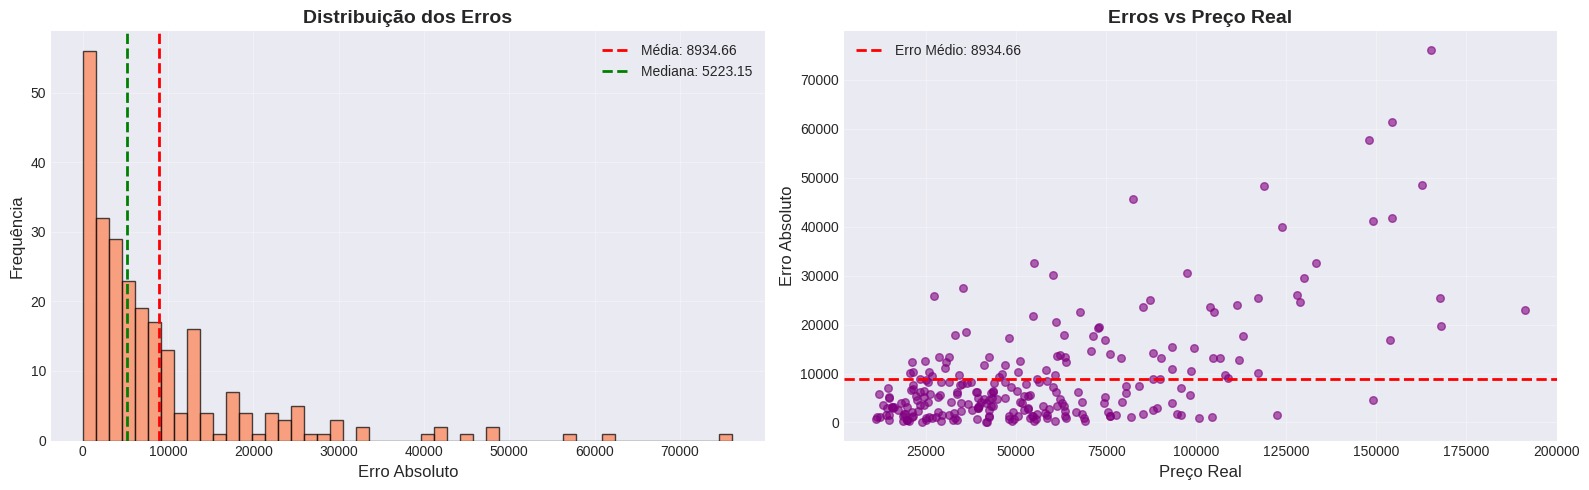


💡 INSIGHTS SOBRE OS ERROS

Erro médio em laptops CAROS (>= 74498.76): 17679.68
Erro médio em laptops BARATOS (<= 28822.48): 4531.10

⚠️ O modelo tem mais dificuldade com laptops CAROS


In [ ]:
# @title
# Análise de Erros - Identificar casos com maior erro
print("="*80)
print("ANÁLISE DE ERROS - ONDE O MODELO ERRA MAIS?")
print("="*80)

# Usar o melhor modelo disponível
if 'rf_best_model' in globals():
    analysis_model = rf_best_model
    model_name = "Random Forest Otimizado"
else:
    analysis_model = rf_model
    model_name = "Random Forest"

y_pred = analysis_model.predict(X_test)
residuals = np.abs(y_test - y_pred)

# Criar DataFrame para análise
error_analysis = X_test.copy()
error_analysis['True_Price'] = y_test.values
error_analysis['Predicted_Price'] = y_pred
error_analysis['Error'] = residuals.values

# Top 10 maiores erros
top_errors = error_analysis.nlargest(10, 'Error')
print(f"\n📉 Top 10 Maiores Erros ({model_name}):")
print(f"\n{'Real':<12} {'Previsto':<12} {'Erro':<12}")
print("-" * 40)
for _, row in top_errors.iterrows():
    print(f"{row['True_Price']:<12.2f} {row['Predicted_Price']:<12.2f} {row['Error']:<12.2f}")

# Estatísticas dos erros
print("\n" + "="*80)
print("ESTATÍSTICAS DOS ERROS")
print("="*80)
print(f"Erro Médio (MAE): {residuals.mean():.2f}")
print(f"Erro Mediano: {residuals.median():.2f}")
print(f"Erro Mínimo: {residuals.min():.2f}")
print(f"Erro Máximo: {residuals.max():.2f}")
print(f"Desvio Padrão dos Erros: {residuals.std():.2f}")

# Percentis
print(f"\nPercentis dos Erros:")
print(f"  25%: {residuals.quantile(0.25):.2f}")
print(f"  50%: {residuals.quantile(0.50):.2f}")
print(f"  75%: {residuals.quantile(0.75):.2f}")
print(f"  90%: {residuals.quantile(0.90):.2f}")
print(f"  95%: {residuals.quantile(0.95):.2f}")

# Distribuição dos erros
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma dos erros
axes[0].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0].axvline(residuals.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Média: {residuals.mean():.2f}')
axes[0].axvline(residuals.median(), color='green', linestyle='--', linewidth=2,
                label=f'Mediana: {residuals.median():.2f}')
axes[0].set_xlabel('Erro Absoluto', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)
axes[0].set_title('Distribuição dos Erros', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Erros vs Preço Real
axes[1].scatter(y_test, residuals, alpha=0.6, s=30, color='purple')
axes[1].axhline(y=residuals.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Erro Médio: {residuals.mean():.2f}')
axes[1].set_xlabel('Preço Real', fontsize=12)
axes[1].set_ylabel('Erro Absoluto', fontsize=12)
axes[1].set_title('Erros vs Preço Real', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Insight sobre os erros
print("\n" + "="*80)
print("💡 INSIGHTS SOBRE OS ERROS")
print("="*80)

high_price = y_test.quantile(0.75)
low_price = y_test.quantile(0.25)

high_price_errors = error_analysis[error_analysis['True_Price'] >= high_price]['Error'].mean()
low_price_errors = error_analysis[error_analysis['True_Price'] <= low_price]['Error'].mean()

print(f"\nErro médio em laptops CAROS (>= {high_price:.2f}): {high_price_errors:.2f}")
print(f"Erro médio em laptops BARATOS (<= {low_price:.2f}): {low_price_errors:.2f}")

if high_price_errors > low_price_errors:
    print("\n⚠️ O modelo tem mais dificuldade com laptops CAROS")
else:
    print("\n⚠️ O modelo tem mais dificuldade com laptops BARATOS")

### 10.6 Random Forest Otimizado com GridSearchCV

In [ ]:
"""### 10.6 Otimização Avançada do Random Forest com GridSearchCV"""

# @title
# Random Forest Otimizado com GridSearchCV
print("="*80)
print("🚀 OTIMIZAÇÃO AVANÇADA - RANDOM FOREST COM GRIDSEARCHCV")
print("="*80)
print("\n📚 Estratégia: Grid inteligente baseado em literatura 2024")
print("   • max_depth mais profundo (20-40) vs anterior (10)")
print("   • n_estimators mais alto (500-1000)")
print("   • max_features controlado ('sqrt' ou 'log2')\n")

# Grid de hiperparâmetros otimizado
param_grid_rf = {
    'n_estimators': [500, 750, 1000],
    'max_depth': [20, 30, 40],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]
}

print("🔍 Grid de Hiperparâmetros:")
for param, values in param_grid_rf.items():
    print(f"   • {param}: {values}")

total_combinations_rf = 3 * 3 * 2 * 2 * 2 * 1
print(f"\n📊 Total de combinações: {total_combinations_rf}")
print(f"⏱️  Tempo estimado: ~15-25 minutos\n")

# GridSearchCV
print("🔧 Configurando GridSearchCV...")
rf_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=5,
    scoring='neg_mean_absolute_error',
    verbose=2,
    n_jobs=-1,
    return_train_score=True
)

print("\n" + "="*80)
print("⚙️  INICIANDO GRID SEARCH - RANDOM FOREST")
print("="*80)
print("Aguarde... Isso pode levar 15-25 minutos.\n")

start_time = time.time()
rf_grid_search.fit(X_train, y_train)
elapsed_time = (time.time() - start_time) / 60

print(f"\n✅ Grid Search concluído em {elapsed_time:.2f} minutos!\n")

# Melhores parâmetros
print("="*80)
print("🏆 MELHORES HIPERPARÂMETROS ENCONTRADOS")
print("="*80)
best_params_rf = rf_grid_search.best_params_
for param, value in best_params_rf.items():
    print(f"   • {param}: {value}")

print(f"\n📊 Melhor Score (CV MAE): {-rf_grid_search.best_score_:.2f}")

# Modelo otimizado
rf_grid_model = rf_grid_search.best_estimator_

# Predições
y_train_pred_rf_grid = rf_grid_model.predict(X_train)
y_test_pred_rf_grid = rf_grid_model.predict(X_test)

# Métricas
train_mae_rf_grid = mean_absolute_error(y_train, y_train_pred_rf_grid)
test_mae_rf_grid = mean_absolute_error(y_test, y_test_pred_rf_grid)
train_rmse_rf_grid = np.sqrt(mean_squared_error(y_train, y_train_pred_rf_grid))
test_rmse_rf_grid = np.sqrt(mean_squared_error(y_test, y_test_pred_rf_grid))
train_r2_rf_grid = r2_score(y_train, y_train_pred_rf_grid)
test_r2_rf_grid = r2_score(y_test, y_test_pred_rf_grid)

print("\n" + "="*80)
print("📊 MÉTRICAS DO RANDOM FOREST OTIMIZADO (GRIDSEARCH)")
print("="*80)
print(f"\n🔹 Treino:")
print(f"   MAE:  {train_mae_rf_grid:.2f}")
print(f"   RMSE: {train_rmse_rf_grid:.2f}")
print(f"   R²:   {train_r2_rf_grid:.4f}")

print(f"\n🔹 Teste:")
if test_mae_rf_grid < 7500:
    print(f"   MAE:  {test_mae_rf_grid:.2f} ✅ OBJETIVO ATINGIDO!")
else:
    print(f"   MAE:  {test_mae_rf_grid:.2f} ⚠️ Ainda {test_mae_rf_grid - 7500:.2f} acima do objetivo (7500)")
print(f"   RMSE: {test_rmse_rf_grid:.2f}")
print(f"   R²:   {test_r2_rf_grid:.4f}")

# Cross-validation
cv_scores_rf_grid = cross_val_score(rf_grid_model, X_train, y_train, cv=5,
                                    scoring='neg_mean_absolute_error')
cv_mae_rf_grid = -cv_scores_rf_grid.mean()
print(f"\n📈 5-Fold CV MAE: {cv_mae_rf_grid:.2f} (±{cv_scores_rf_grid.std():.2f})")

# Comparação
print("\n" + "="*80)
print("📊 COMPARAÇÃO: RANDOM FOREST - TODAS AS VERSÕES")
print("="*80)
print(f"   1. Inicial:           Test MAE = {test_mae_rf:.2f}")
print(f"   2. RandomizedSearch:  Test MAE = {test_mae_rf_opt:.2f}")
print(f"   3. GridSearch:        Test MAE = {test_mae_rf_grid:.2f}")

delta_initial = test_mae_rf - test_mae_rf_grid
delta_randomized = test_mae_rf_opt - test_mae_rf_grid

print(f"\n💡 Melhorias:")
if delta_initial > 0:
    print(f"   ✅ vs Inicial: Redução de {delta_initial:.2f} ({(delta_initial/test_mae_rf)*100:.2f}%)")
else:
    print(f"   ⚠️ vs Inicial: Aumento de {abs(delta_initial):.2f}")

if delta_randomized > 0:
    print(f"   ✅ vs RandomizedSearchCV: Redução de {delta_randomized:.2f} ({(delta_randomized/test_mae_rf_opt)*100:.2f}%)")
else:
    print(f"   ⚠️ vs RandomizedSearchCV: Aumento de {abs(delta_randomized):.2f}")

🚀 OTIMIZAÇÃO AVANÇADA - RANDOM FOREST COM GRIDSEARCHCV

📚 Estratégia: Grid inteligente baseado em literatura 2024
   • max_depth mais profundo (20-40) vs anterior (10)
   • n_estimators mais alto (500-1000)
   • max_features controlado ('sqrt' ou 'log2')

🔍 Grid de Hiperparâmetros:
   • n_estimators: [500, 750, 1000]
   • max_depth: [20, 30, 40]
   • min_samples_split: [2, 5]
   • min_samples_leaf: [1, 2]
   • max_features: ['sqrt', 'log2']
   • bootstrap: [True]

📊 Total de combinações: 72
⏱️  Tempo estimado: ~15-25 minutos

🔧 Configurando GridSearchCV...

⚙️  INICIANDO GRID SEARCH - RANDOM FOREST
Aguarde... Isso pode levar 15-25 minutos.

Fitting 5 folds for each of 72 candidates, totalling 360 fits

✅ Grid Search concluído em 8.53 minutos!

🏆 MELHORES HIPERPARÂMETROS ENCONTRADOS
   • bootstrap: True
   • max_depth: 20
   • max_features: sqrt
   • min_samples_leaf: 1
   • min_samples_split: 2
   • n_estimators: 500

📊 Melhor Score (CV MAE): 10785.68

📊 MÉTRICAS DO RANDOM FOREST OTIMI

### 10.7 XGBoost Otimizado com GridSearchCV




In [ ]:
"""### 10.7 Otimização Avançada do XGBoost com GridSearchCV"""

# @title
# XGBoost Otimizado com GridSearchCV
print("\n" + "="*80)
print("🚀 OTIMIZAÇÃO AVANÇADA - XGBOOST COM GRIDSEARCHCV")
print("="*80)
print("\n📚 Estratégia: Otimização sistemática de 6 hiperparâmetros")
print("   • learning_rate, max_depth, min_child_weight")
print("   • subsample, colsample_bytree, gamma\n")

# Grid de hiperparâmetros
param_grid_xgb = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.3],
    'n_estimators': [500]
}

print("🔍 Grid de Hiperparâmetros XGBoost:")
for param, values in param_grid_xgb.items():
    if param != 'n_estimators':
        print(f"   • {param}: {values}")

total_combinations_xgb = 3 * 3 * 3 * 3 * 3 * 3
print(f"\n📊 Total de combinações: {total_combinations_xgb}")
print(f"⏱️  Tempo estimado: ~20-35 minutos\n")

# Preparar dados para XGBoost
X_train_xgb_grid = X_train.copy()
X_test_xgb_grid = X_test.copy()

if 'Gpu_Dedicated' in X_train_xgb_grid.columns:
    X_train_xgb_grid['Gpu_Dedicated'] = X_train_xgb_grid['Gpu_Dedicated'].astype(int)
    X_test_xgb_grid['Gpu_Dedicated'] = X_test_xgb_grid['Gpu_Dedicated'].astype(int)

# GridSearchCV
print("🔧 Configurando GridSearchCV...")
xgb_grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_xgb,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=2,
    n_jobs=-1,
    return_train_score=True
)

print("\n" + "="*80)
print("⚙️  INICIANDO GRID SEARCH - XGBOOST")
print("="*80)
print("Aguarde... Isso pode levar 20-35 minutos.\n")

start_time_xgb = time.time()
xgb_grid_search.fit(X_train_xgb_grid, y_train)
elapsed_time_xgb = (time.time() - start_time_xgb) / 60

print(f"\n✅ Grid Search concluído em {elapsed_time_xgb:.2f} minutos!\n")

# Melhores parâmetros
print("="*80)
print("🏆 MELHORES HIPERPARÂMETROS ENCONTRADOS - XGBOOST")
print("="*80)
best_params_xgb_grid = xgb_grid_search.best_params_
for param, value in best_params_xgb_grid.items():
    print(f"   • {param}: {value}")

print(f"\n📊 Melhor Score (CV MAE): {-xgb_grid_search.best_score_:.2f}")

# Modelo otimizado
xgb_grid_model = xgb_grid_search.best_estimator_

# Predições
y_train_pred_xgb_grid = xgb_grid_model.predict(X_train_xgb_grid)
y_test_pred_xgb_grid = xgb_grid_model.predict(X_test_xgb_grid)

# Métricas
train_mae_xgb_grid = mean_absolute_error(y_train, y_train_pred_xgb_grid)
test_mae_xgb_grid = mean_absolute_error(y_test, y_test_pred_xgb_grid)
train_rmse_xgb_grid = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb_grid))
test_rmse_xgb_grid = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb_grid))
train_r2_xgb_grid = r2_score(y_train, y_train_pred_xgb_grid)
test_r2_xgb_grid = r2_score(y_test, y_test_pred_xgb_grid)

print("\n" + "="*80)
print("📊 MÉTRICAS DO XGBOOST OTIMIZADO (GRIDSEARCH)")
print("="*80)
print(f"\n🔹 Treino:")
print(f"   MAE:  {train_mae_xgb_grid:.2f}")
print(f"   RMSE: {train_rmse_xgb_grid:.2f}")
print(f"   R²:   {train_r2_xgb_grid:.4f}")

print(f"\n🔹 Teste:")
if test_mae_xgb_grid < 7500:
    print(f"   MAE:  {test_mae_xgb_grid:.2f} ✅ OBJETIVO ATINGIDO!")
    print(f"   🎉 Margem de {7500 - test_mae_xgb_grid:.2f} INR abaixo!")
else:
    print(f"   MAE:  {test_mae_xgb_grid:.2f} ⚠️ Ainda {test_mae_xgb_grid - 7500:.2f} acima do objetivo")
print(f"   RMSE: {test_rmse_xgb_grid:.2f}")
print(f"   R²:   {test_r2_xgb_grid:.4f}")

# Cross-validation
cv_scores_xgb_grid = cross_val_score(xgb_grid_model, X_train_xgb_grid, y_train,
                                     cv=5, scoring='neg_mean_absolute_error')
cv_mae_xgb_grid = -cv_scores_xgb_grid.mean()
print(f"\n📈 5-Fold CV MAE: {cv_mae_xgb_grid:.2f} (±{cv_scores_xgb_grid.std():.2f})")

# Comparação
print("\n" + "="*80)
print("📊 COMPARAÇÃO: XGBOOST - VERSÕES")
print("="*80)
print(f"   1. XGBoost Original:  Test MAE = {test_mae_xgb:.2f}")
print(f"   2. XGBoost GridSearch: Test MAE = {test_mae_xgb_grid:.2f}")

delta_xgb = test_mae_xgb - test_mae_xgb_grid
if delta_xgb > 0:
    print(f"\n   ✅ Melhoria: {delta_xgb:.2f} ({(delta_xgb/test_mae_xgb)*100:.2f}%)")
    gap_to_target = test_mae_xgb_grid - 7500
    if gap_to_target > 0:
        print(f"   📊 Restam {gap_to_target:.2f} INR para atingir o objetivo!")
    else:
        print(f"   🎉 OBJETIVO ATINGIDO! {abs(gap_to_target):.2f} INR abaixo!")
else:
    print(f"\n   ⚠️ Piora: {abs(delta_xgb):.2f}")


🚀 OTIMIZAÇÃO AVANÇADA - XGBOOST COM GRIDSEARCHCV

📚 Estratégia: Otimização sistemática de 6 hiperparâmetros
   • learning_rate, max_depth, min_child_weight
   • subsample, colsample_bytree, gamma

🔍 Grid de Hiperparâmetros XGBoost:
   • learning_rate: [0.01, 0.05, 0.1]
   • max_depth: [5, 7, 9]
   • min_child_weight: [1, 3, 5]
   • subsample: [0.7, 0.8, 0.9]
   • colsample_bytree: [0.7, 0.8, 0.9]
   • gamma: [0, 0.1, 0.3]

📊 Total de combinações: 729
⏱️  Tempo estimado: ~20-35 minutos

🔧 Configurando GridSearchCV...

⚙️  INICIANDO GRID SEARCH - XGBOOST
Aguarde... Isso pode levar 20-35 minutos.

Fitting 3 folds for each of 729 candidates, totalling 2187 fits

✅ Grid Search concluído em 12.68 minutos!

🏆 MELHORES HIPERPARÂMETROS ENCONTRADOS - XGBOOST
   • colsample_bytree: 0.9
   • gamma: 0
   • learning_rate: 0.05
   • max_depth: 5
   • min_child_weight: 3
   • n_estimators: 500
   • subsample: 0.9

📊 Melhor Score (CV MAE): 9744.54

📊 MÉTRICAS DO XGBOOST OTIMIZADO (GRIDSEARCH)

🔹 Trein

### 10.8 Log Transformation do Target

In [ ]:
"""### 15.1 Log Transformation do Target"""

# @title
print("="*80)
print("📊 ESTRATÉGIA 1: LOG TRANSFORMATION DO TARGET")
print("="*80)

# Aplicar log no target
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Treinar XGBoost com target transformado
print("\n⚙️  Treinando XGBoost com target em escala logarítmica...")

xgb_log = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

# Preparar dados
X_train_xgb_log = X_train.copy()
X_test_xgb_log = X_test.copy()

if 'Gpu_Dedicated' in X_train_xgb_log.columns:
    X_train_xgb_log['Gpu_Dedicated'] = X_train_xgb_log['Gpu_Dedicated'].astype(int)
    X_test_xgb_log['Gpu_Dedicated'] = X_test_xgb_log['Gpu_Dedicated'].astype(int)

xgb_log.fit(X_train_xgb_log, y_train_log)

# Predições (reverter de log para escala original)
y_train_pred_log = np.expm1(xgb_log.predict(X_train_xgb_log))
y_test_pred_log = np.expm1(xgb_log.predict(X_test_xgb_log))

# Métricas
train_mae_log = mean_absolute_error(y_train, y_train_pred_log)
test_mae_log = mean_absolute_error(y_test, y_test_pred_log)
train_r2_log = r2_score(y_train, y_train_pred_log)
test_r2_log = r2_score(y_test, y_test_pred_log)

print("\n" + "="*80)
print("📊 RESULTADOS - XGBOOST COM LOG TRANSFORMATION")
print("="*80)
print(f"\n🔹 Treino:")
print(f"   MAE:  {train_mae_log:.2f}")
print(f"   R²:   {train_r2_log:.4f}")

print(f"\n🔹 Teste:")
if test_mae_log < 7500:
    print(f"   MAE:  {test_mae_log:.2f} ✅ OBJETIVO ATINGIDO!")
    print(f"   🎉 {7500 - test_mae_log:.2f} INR abaixo do objetivo!")
else:
    print(f"   MAE:  {test_mae_log:.2f} ⚠️ {test_mae_log - 7500:.2f} acima do objetivo")
print(f"   R²:   {test_r2_log:.4f}")

# Comparação
delta_log = test_mae_xgb - test_mae_log
print(f"\n💡 Comparação com XGBoost Original:")
print(f"   Antes (original): {test_mae_xgb:.2f}")
print(f"   Depois (log):     {test_mae_log:.2f}")
if delta_log > 0:
    print(f"   ✅ Melhoria: {delta_log:.2f} INR ({(delta_log/test_mae_xgb)*100:.1f}%)")
else:
    print(f"   ⚠️ Piora: {abs(delta_log):.2f} INR")

📊 ESTRATÉGIA 1: LOG TRANSFORMATION DO TARGET

⚙️  Treinando XGBoost com target em escala logarítmica...

📊 RESULTADOS - XGBOOST COM LOG TRANSFORMATION

🔹 Treino:
   MAE:  2097.48
   R²:   0.9887

🔹 Teste:
   MAE:  8168.71 ⚠️ 668.71 acima do objetivo
   R²:   0.8512

💡 Comparação com XGBoost Original:
   Antes (original): 8275.11
   Depois (log):     8168.71
   ✅ Melhoria: 106.40 INR (1.3%)


## 11. Comparação Final dos Modelos


📊 SEÇÃO 11: COMPARAÇÃO FINAL CONSOLIDADA - TODOS OS MODELOS

✅ Total de modelos compilados: 8

📋 RANKING COMPLETO DE MODELOS

 Ranking                           Modelo  Test MAE Test RMSE Test R² Gap do Objetivo Gap (%)
       1        XGBoost (Log Transform) ⭐  8,168.71 13,903.73  0.8512         +668.71  +8.92%
       2               XGBoost (Original)  8,275.11 13,700.08  0.8555         +775.11 +10.33%
       3             XGBoost (GridSearch)  8,414.62 13,989.89  0.8493         +914.62 +12.19%
       4          Random Forest (Inicial)  8,426.23 13,775.99  0.8539         +926.23 +12.35%
       5       Random Forest (GridSearch)  8,856.89 14,085.16  0.8473       +1,356.89 +18.09%
       6 Random Forest (RandomizedSearch)  8,934.66 14,163.62  0.8456       +1,434.66 +19.13%
       7                Gradient Boosting  9,747.90 14,107.31  0.8468       +2,247.90 +29.97%
       8                Linear Regression 12,415.09 17,104.27  0.7748       +4,915.09 +65.53%

🏆 MELHOR MODELO

   📌 Nome

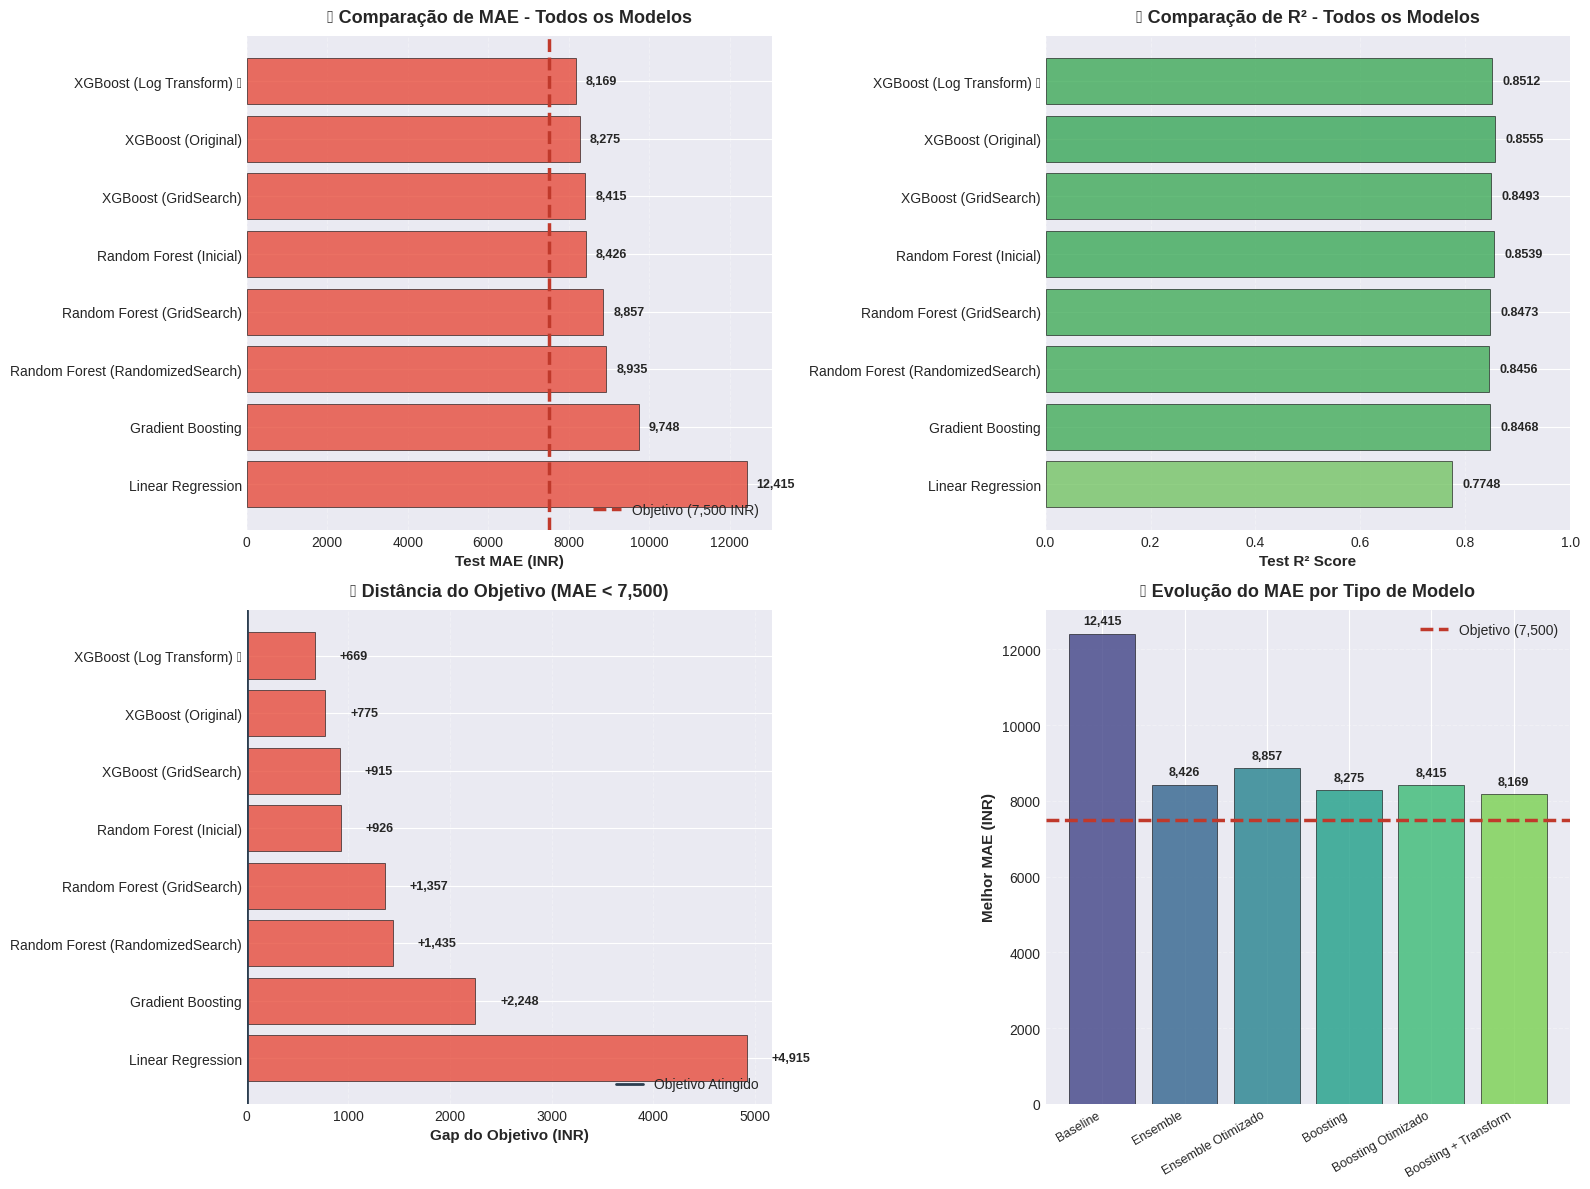


📋 RESUMO POR TIPO DE MODELO
                      Melhor MAE  MAE Médio  Melhor R²  Qtd Modelos
Tipo                                                               
Boosting + Transform     8168.71    8168.71       0.85            1
Boosting                 8275.11    9011.50       0.86            2
Boosting Otimizado       8414.62    8414.62       0.85            1
Ensemble                 8426.23    8426.23       0.85            1
Ensemble Otimizado       8856.89    8895.77       0.85            2
Baseline                12415.09   12415.09       0.77            1

✅ SEÇÃO 11 CONCLUÍDA

   🏆 Melhor Modelo: XGBoost (Log Transform) ⭐
   📊 MAE Final: 8,168.71 INR
   📈 R² Final: 0.8512
   🎯 Gap: +668.71 INR (+8.92%)
   
   ➡️ Prossiga para Seção 12 (Conclusão) e Seção 13 (SHAP)



In [ ]:
"""
## 11. COMPARAÇÃO FINAL DOS MODELOS
Esta seção consolida TODOS os modelos treinados.
Gera visualizações comparativas e identifica o melhor modelo.
"""

# @title
# ==========================================
# 11. COMPARAÇÃO FINAL DOS MODELOS
# ==========================================

print("\n" + "="*80)
print("📊 SEÇÃO 11: COMPARAÇÃO FINAL CONSOLIDADA - TODOS OS MODELOS")
print("="*80)

# ==========================================
# 11.1 COMPILAR RESULTADOS DE TODOS OS MODELOS
# ==========================================

# Dicionário para armazenar todos os modelos
modelos_resultados = {}

# 1. Linear Regression (Baseline)
if 'test_mae_lr' in globals():
    modelos_resultados['Linear Regression'] = {
        'MAE': test_mae_lr,
        'RMSE': test_rmse_lr,
        'R2': test_r2_lr,
        'Tipo': 'Baseline'
    }

# 2. Random Forest Inicial
if 'test_mae_rf' in globals():
    modelos_resultados['Random Forest (Inicial)'] = {
        'MAE': test_mae_rf,
        'RMSE': test_rmse_rf,
        'R2': test_r2_rf,
        'Tipo': 'Ensemble'
    }

# 3. Random Forest RandomizedSearchCV
if 'test_mae_rf_opt' in globals():
    modelos_resultados['Random Forest (RandomizedSearch)'] = {
        'MAE': test_mae_rf_opt,
        'RMSE': test_rmse_rf_opt,
        'R2': test_r2_rf_opt,
        'Tipo': 'Ensemble Otimizado'
    }

# 4. Random Forest GridSearchCV
if 'test_mae_rf_grid' in globals():
    modelos_resultados['Random Forest (GridSearch)'] = {
        'MAE': test_mae_rf_grid,
        'RMSE': test_rmse_rf_grid,
        'R2': test_r2_rf_grid,
        'Tipo': 'Ensemble Otimizado'
    }

# 5. Gradient Boosting
if 'test_mae_gb' in globals():
    modelos_resultados['Gradient Boosting'] = {
        'MAE': test_mae_gb,
        'RMSE': test_rmse_gb,
        'R2': test_r2_gb,
        'Tipo': 'Boosting'
    }

# 6. XGBoost Original
if 'test_mae_xgb' in globals():
    modelos_resultados['XGBoost (Original)'] = {
        'MAE': test_mae_xgb,
        'RMSE': test_rmse_xgb,
        'R2': test_r2_xgb,
        'Tipo': 'Boosting'
    }

# 7. XGBoost GridSearchCV
if 'test_mae_xgb_grid' in globals():
    modelos_resultados['XGBoost (GridSearch)'] = {
        'MAE': test_mae_xgb_grid,
        'RMSE': test_rmse_xgb_grid,
        'R2': test_r2_xgb_grid,
        'Tipo': 'Boosting Otimizado'
    }

# 8. XGBoost Log Transformation ⭐ (Melhor esperado)
if 'test_mae_log' in globals():
    # Calcular RMSE para Log Transformation se não existir
    if 'test_rmse_log' not in globals():
        test_rmse_log = np.sqrt(mean_squared_error(y_test, y_test_pred_log))

    modelos_resultados['XGBoost (Log Transform) ⭐'] = {
        'MAE': test_mae_log,
        'RMSE': test_rmse_log,
        'R2': test_r2_log,
        'Tipo': 'Boosting + Transform'
    }

# ==========================================
# 11.2 CRIAR DATAFRAME DE COMPARAÇÃO
# ==========================================

print(f"\n✅ Total de modelos compilados: {len(modelos_resultados)}")

# Criar DataFrame
df_comparacao = pd.DataFrame([
    {
        'Modelo': nome,
        'Test MAE': dados['MAE'],
        'Test RMSE': dados['RMSE'],
        'Test R²': dados['R2'],
        'Tipo': dados['Tipo']
    }
    for nome, dados in modelos_resultados.items()
])

# Ordenar por MAE (menor = melhor)
df_comparacao = df_comparacao.sort_values('Test MAE').reset_index(drop=True)

# Adicionar colunas de análise
objetivo_mae = 7500
df_comparacao['Atingiu Objetivo'] = df_comparacao['Test MAE'] < objetivo_mae
df_comparacao['Gap do Objetivo'] = df_comparacao['Test MAE'] - objetivo_mae
df_comparacao['Gap (%)'] = ((df_comparacao['Test MAE'] - objetivo_mae) / objetivo_mae * 100).round(2)
df_comparacao['Ranking'] = range(1, len(df_comparacao) + 1)

# ==========================================
# 11.3 EXIBIR TABELA COMPARATIVA
# ==========================================

print("\n" + "="*80)
print("📋 RANKING COMPLETO DE MODELOS")
print("="*80)

# Formatar para exibição
df_display = df_comparacao[['Ranking', 'Modelo', 'Test MAE', 'Test RMSE', 'Test R²', 'Gap do Objetivo', 'Gap (%)']].copy()
df_display['Test MAE'] = df_display['Test MAE'].apply(lambda x: f"{x:,.2f}")
df_display['Test RMSE'] = df_display['Test RMSE'].apply(lambda x: f"{x:,.2f}")
df_display['Test R²'] = df_display['Test R²'].apply(lambda x: f"{x:.4f}")
df_display['Gap do Objetivo'] = df_display['Gap do Objetivo'].apply(lambda x: f"{x:+,.2f}")
df_display['Gap (%)'] = df_display['Gap (%)'].apply(lambda x: f"{x:+.2f}%")

print("\n" + df_display.to_string(index=False))

# ==========================================
# 11.4 DESTACAR MELHOR MODELO
# ==========================================

melhor = df_comparacao.iloc[0]
pior = df_comparacao.iloc[-1]

print("\n" + "="*80)
print("🏆 MELHOR MODELO")
print("="*80)
print(f"""
   📌 Nome:     {melhor['Modelo']}
   📊 Tipo:     {melhor['Tipo']}

   📈 Métricas:
      • MAE:    {melhor['Test MAE']:,.2f} INR
      • RMSE:   {melhor['Test RMSE']:,.2f} INR
      • R²:     {melhor['Test R²']:.4f} ({melhor['Test R²']*100:.2f}% da variância explicada)
""")

if melhor['Atingiu Objetivo']:
    print(f"   🎉 OBJETIVO ATINGIDO!")
    print(f"   ✅ MAE está {abs(melhor['Gap do Objetivo']):,.2f} INR ABAIXO do objetivo!")
else:
    print(f"   ⚠️  Objetivo não atingido")
    print(f"   📊 Gap: {melhor['Gap do Objetivo']:,.2f} INR ({melhor['Gap (%)']:.2f}% acima)")

# ==========================================
# 11.5 ANÁLISE DE EVOLUÇÃO
# ==========================================

print("\n" + "="*80)
print("📈 EVOLUÇÃO DO PROJETO")
print("="*80)

# Baseline
if 'test_mae_lr' in globals():
    baseline_mae = test_mae_lr
    print(f"\n   🔹 Baseline (Linear Regression):  {baseline_mae:,.2f} INR")

# Primeiro modelo ensemble
if 'test_mae_rf' in globals():
    print(f"   🔹 Random Forest (Inicial):       {test_mae_rf:,.2f} INR")

# Melhor modelo
print(f"   🔹 Melhor Modelo Atual:           {melhor['Test MAE']:,.2f} INR")

# Calcular redução total
if 'test_mae_lr' in globals():
    reducao_total = baseline_mae - melhor['Test MAE']
    reducao_pct = (reducao_total / baseline_mae) * 100
    print(f"\n   🎯 Redução Total: {reducao_total:,.2f} INR ({reducao_pct:.1f}%)")

# ==========================================
# 11.6 VISUALIZAÇÕES COMPARATIVAS
# ==========================================

print("\n" + "="*80)
print("📊 GERANDO VISUALIZAÇÕES COMPARATIVAS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Cores baseadas no objetivo
cores_mae = ['#2ecc71' if mae < objetivo_mae else '#e74c3c'
             for mae in df_comparacao['Test MAE']]

# Gráfico 1: Comparação de MAE (barras horizontais)
ax1 = axes[0, 0]
bars1 = ax1.barh(df_comparacao['Modelo'], df_comparacao['Test MAE'],
                  color=cores_mae, alpha=0.8, edgecolor='black', linewidth=0.5)
ax1.axvline(x=objetivo_mae, color='#c0392b', linestyle='--', linewidth=2.5,
            label=f'Objetivo ({objetivo_mae:,} INR)')
ax1.set_xlabel('Test MAE (INR)', fontsize=11, fontweight='bold')
ax1.set_title('📊 Comparação de MAE - Todos os Modelos', fontsize=13, fontweight='bold', pad=10)
ax1.legend(loc='lower right', fontsize=10)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Adicionar valores nas barras
for idx, (mae, modelo) in enumerate(zip(df_comparacao['Test MAE'], df_comparacao['Modelo'])):
    offset = max(df_comparacao['Test MAE']) * 0.02
    ax1.text(mae + offset, idx, f'{mae:,.0f}', va='center', fontsize=9, fontweight='bold')

# Gráfico 2: Comparação de R²
ax2 = axes[0, 1]
cores_r2 = plt.cm.RdYlGn(df_comparacao['Test R²'])
bars2 = ax2.barh(df_comparacao['Modelo'], df_comparacao['Test R²'],
                  color=cores_r2, alpha=0.8, edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Test R² Score', fontsize=11, fontweight='bold')
ax2.set_title('📈 Comparação de R² - Todos os Modelos', fontsize=13, fontweight='bold', pad=10)
ax2.invert_yaxis()
ax2.set_xlim([0, 1])
ax2.grid(axis='x', alpha=0.3, linestyle='--')

# Adicionar valores
for idx, (r2, modelo) in enumerate(zip(df_comparacao['Test R²'], df_comparacao['Modelo'])):
    ax2.text(r2 + 0.02, idx, f'{r2:.4f}', va='center', fontsize=9, fontweight='bold')

# Gráfico 3: Gap do Objetivo
ax3 = axes[1, 0]
cores_gap = ['#2ecc71' if gap < 0 else '#e74c3c' for gap in df_comparacao['Gap do Objetivo']]
bars3 = ax3.barh(df_comparacao['Modelo'], df_comparacao['Gap do Objetivo'],
                  color=cores_gap, alpha=0.8, edgecolor='black', linewidth=0.5)
ax3.axvline(x=0, color='#2c3e50', linestyle='-', linewidth=2, label='Objetivo Atingido')
ax3.set_xlabel('Gap do Objetivo (INR)', fontsize=11, fontweight='bold')
ax3.set_title('🎯 Distância do Objetivo (MAE < 7,500)', fontsize=13, fontweight='bold', pad=10)
ax3.legend(loc='lower right', fontsize=10)
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3, linestyle='--')

# Adicionar valores
for idx, (gap, modelo) in enumerate(zip(df_comparacao['Gap do Objetivo'], df_comparacao['Modelo'])):
    offset = max(abs(df_comparacao['Gap do Objetivo'])) * 0.05
    pos = gap + offset if gap >= 0 else gap - offset
    align = 'left' if gap >= 0 else 'right'
    ax3.text(pos, idx, f'{gap:+,.0f}', va='center', ha=align, fontsize=9, fontweight='bold')

# Gráfico 4: Evolução MAE por Tipo de Modelo
ax4 = axes[1, 1]

# Agrupar por tipo
tipos_ordem = ['Baseline', 'Ensemble', 'Ensemble Otimizado', 'Boosting', 'Boosting Otimizado', 'Boosting + Transform']
df_por_tipo = df_comparacao.groupby('Tipo')['Test MAE'].min().reindex(
    [t for t in tipos_ordem if t in df_comparacao['Tipo'].values]
)

cores_tipo = plt.cm.viridis(np.linspace(0.2, 0.8, len(df_por_tipo)))
bars4 = ax4.bar(range(len(df_por_tipo)), df_por_tipo.values, color=cores_tipo,
                alpha=0.8, edgecolor='black', linewidth=0.5)
ax4.axhline(y=objetivo_mae, color='#c0392b', linestyle='--', linewidth=2.5,
            label=f'Objetivo ({objetivo_mae:,})')
ax4.set_xticks(range(len(df_por_tipo)))
ax4.set_xticklabels(df_por_tipo.index, rotation=30, ha='right', fontsize=9)
ax4.set_ylabel('Melhor MAE (INR)', fontsize=11, fontweight='bold')
ax4.set_title('📉 Evolução do MAE por Tipo de Modelo', fontsize=13, fontweight='bold', pad=10)
ax4.legend(loc='upper right', fontsize=10)
ax4.grid(axis='y', alpha=0.3, linestyle='--')

# Adicionar valores
for idx, mae in enumerate(df_por_tipo.values):
    ax4.text(idx, mae + max(df_por_tipo) * 0.02, f'{mae:,.0f}',
             ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# 11.7 TABELA RESUMO POR TIPO DE MODELO
# ==========================================

print("\n" + "="*80)
print("📋 RESUMO POR TIPO DE MODELO")
print("="*80)

resumo_tipo = df_comparacao.groupby('Tipo').agg({
    'Test MAE': ['min', 'mean'],
    'Test R²': 'max',
    'Modelo': 'count'
}).round(2)

resumo_tipo.columns = ['Melhor MAE', 'MAE Médio', 'Melhor R²', 'Qtd Modelos']
resumo_tipo = resumo_tipo.sort_values('Melhor MAE')

print(resumo_tipo.to_string())

# ==========================================
# 11.8 SALVAR RESULTADOS PARA PRÓXIMAS SEÇÕES
# ==========================================

# Variáveis que serão usadas nas seções 12 e 13
melhor_modelo_nome = melhor['Modelo']
melhor_modelo_mae = melhor['Test MAE']
melhor_modelo_rmse = melhor['Test RMSE']
melhor_modelo_r2 = melhor['Test R²']
melhor_modelo_gap = melhor['Gap do Objetivo']

print("\n" + "="*80)
print("✅ SEÇÃO 11 CONCLUÍDA")
print("="*80)
print(f"""
   🏆 Melhor Modelo: {melhor_modelo_nome}
   📊 MAE Final: {melhor_modelo_mae:,.2f} INR
   📈 R² Final: {melhor_modelo_r2:.4f}
   🎯 Gap: {melhor_modelo_gap:+,.2f} INR ({melhor['Gap (%)']:+.2f}%)

   ➡️ Prossiga para Seção 12 (Conclusão) e Seção 13 (SHAP)
""")

## 12. Conclusão e Insights

A seção de conclusão e insights sumariza todo o projeto. Revisa as etapas de tratamento de dados, feature engineering e modelagem, destacando o melhor modelo e suas métricas. Além disso, apresenta insights cruciais extraídos da análise e sugere próximos passos para otimizações futuras.


🎯 SEÇÃO 12: CONCLUSÃO E INSIGHTS DO PROJETO

📊 SUMÁRIO DO DATASET

   📁 Dataset Original:
      • Registros: 1,303
      • Colunas originais: 12
      • Fonte: laptopData.csv
      
   🧹 Após Tratamento (df_clean):
      • Registros: 1,273
      • Registros removidos: 30

   🎯 Após Remoção de Outliers (df_no_extreme):
      • Registros: 1,266
      • Outliers removidos: 7

⚙️ ENGENHARIA DE FEATURES

   📐 Features para Modelagem: 32
   
   🔧 Categorias de Features Criadas:
      • CPU: Cpu_Speed, Cpu_Brand
      • GPU: Gpu_Dedicated, Gpu_Brand
      • Storage: SSD_GB, HDD_GB, Total_Storage, SSD_Ratio
      • Tela: Screen_Pixels, Is_Touchscreen, Is_IPS, Is_Retina
      • Interações: RAM_x_CPU_Speed, RAM_x_SSD, Storage_x_RAM
      • Scores: Premium_Config, Ultraportable, Gaming_Workstation
      
   💡 Técnica Chave: Log Transformation do Target
      • Transforma distribuição assimétrica em aproximadamente normal
      • Reduz impacto de outliers de preços altos
      • Melhora performan

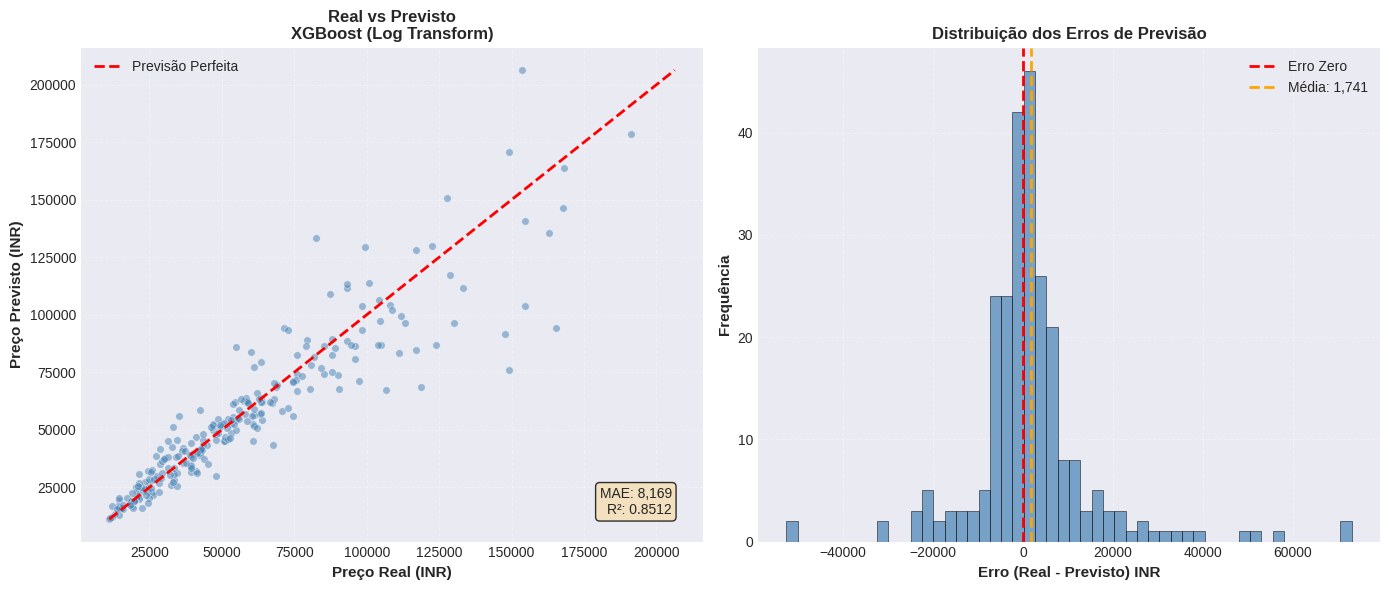


✅ SEÇÃO 12 CONCLUÍDA

   📊 Análise completa do projeto finalizada!
   
   ➡️ Prossiga para Seção 13 (Análise SHAP) para
      interpretabilidade do modelo.



In [ ]:
# -*- coding: utf-8 -*-
"""
## 12. CONCLUSÃO E INSIGHTS
Seção final com sumário do projeto, insights principais e próximos passos.
Utiliza todas as variáveis definidas nas seções anteriores.
"""

# @title
# ==========================================
# 12. CONCLUSÃO E INSIGHTS
# ==========================================

print("\n" + "="*80)
print("🎯 SEÇÃO 12: CONCLUSÃO E INSIGHTS DO PROJETO")
print("="*80)

# ==========================================
# 12.1 SUMÁRIO DO DATASET
# ==========================================

print("\n" + "="*80)
print("📊 SUMÁRIO DO DATASET")
print("="*80)

print(f"""
   📁 Dataset Original:
      • Registros: {len(df):,}
      • Colunas originais: {len(df.columns)}
      • Fonte: laptopData.csv

   🧹 Após Tratamento (df_clean):
      • Registros: {len(df_clean):,}
      • Registros removidos: {len(df) - len(df_clean):,}
""")

# Verificar se df_no_extreme existe
if 'df_no_extreme' in globals():
    print(f"""   🎯 Após Remoção de Outliers (df_no_extreme):
      • Registros: {len(df_no_extreme):,}
      • Outliers removidos: {len(df_clean) - len(df_no_extreme):,}
""")

# ==========================================
# 12.2 ENGENHARIA DE FEATURES
# ==========================================

print("="*80)
print("⚙️ ENGENHARIA DE FEATURES")
print("="*80)

# Contar features usadas
if 'features_to_use' in globals():
    n_features = len(features_to_use)
else:
    n_features = X_train.shape[1]

print(f"""
   📐 Features para Modelagem: {n_features}

   🔧 Categorias de Features Criadas:
      • CPU: Cpu_Speed, Cpu_Brand
      • GPU: Gpu_Dedicated, Gpu_Brand
      • Storage: SSD_GB, HDD_GB, Total_Storage, SSD_Ratio
      • Tela: Screen_Pixels, Is_Touchscreen, Is_IPS, Is_Retina
      • Interações: RAM_x_CPU_Speed, RAM_x_SSD, Storage_x_RAM
      • Scores: Premium_Config, Ultraportable, Gaming_Workstation

   💡 Técnica Chave: Log Transformation do Target
      • Transforma distribuição assimétrica em aproximadamente normal
      • Reduz impacto de outliers de preços altos
      • Melhora performance em previsões de laptops caros
""")

# ==========================================
# 12.3 MODELOS TREINADOS
# ==========================================

print("="*80)
print("🤖 MODELOS TREINADOS")
print("="*80)

modelos_treinados = []

if 'test_mae_lr' in globals():
    modelos_treinados.append(('Linear Regression (Baseline)', test_mae_lr))
if 'test_mae_rf' in globals():
    modelos_treinados.append(('Random Forest (Inicial)', test_mae_rf))
if 'test_mae_rf_opt' in globals():
    modelos_treinados.append(('Random Forest (RandomizedSearch)', test_mae_rf_opt))
if 'test_mae_rf_grid' in globals():
    modelos_treinados.append(('Random Forest (GridSearch)', test_mae_rf_grid))
if 'test_mae_gb' in globals():
    modelos_treinados.append(('Gradient Boosting', test_mae_gb))
if 'test_mae_xgb' in globals():
    modelos_treinados.append(('XGBoost (Original)', test_mae_xgb))
if 'test_mae_xgb_grid' in globals():
    modelos_treinados.append(('XGBoost (GridSearch)', test_mae_xgb_grid))
if 'test_mae_log' in globals():
    modelos_treinados.append(('XGBoost (Log Transform)', test_mae_log))

print(f"\n   📋 Total de Modelos: {len(modelos_treinados)}\n")

for idx, (nome, mae) in enumerate(modelos_treinados, 1):
    status = "✅" if mae < 7500 else "⚠️"
    print(f"      {idx}. {nome}")
    print(f"         MAE: {mae:,.2f} INR {status}")

# ==========================================
# 12.4 MELHOR RESULTADO
# ==========================================

print("\n" + "="*80)
print("🏆 MELHOR RESULTADO ALCANÇADO")
print("="*80)

# Encontrar melhor modelo
melhor_nome, melhor_mae = min(modelos_treinados, key=lambda x: x[1])

# Obter métricas do melhor modelo
if 'XGBoost (Log Transform)' in melhor_nome and 'test_mae_log' in globals():
    melhor_r2 = test_r2_log
    melhor_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_log)) if 'y_test_pred_log' in globals() else 'N/A'
elif 'XGBoost (GridSearch)' in melhor_nome and 'test_mae_xgb_grid' in globals():
    melhor_r2 = test_r2_xgb_grid
    melhor_rmse = test_rmse_xgb_grid
elif 'XGBoost (Original)' in melhor_nome and 'test_mae_xgb' in globals():
    melhor_r2 = test_r2_xgb
    melhor_rmse = test_rmse_xgb
else:
    melhor_r2 = 'N/A'
    melhor_rmse = 'N/A'

objetivo_mae = 7500
gap = melhor_mae - objetivo_mae
gap_pct = (gap / objetivo_mae) * 100

print(f"""
   🎖️ Modelo: {melhor_nome}

   📊 Métricas Finais:
      • MAE:  {melhor_mae:,.2f} INR
      • RMSE: {melhor_rmse:,.2f} INR
      • R²:   {melhor_r2:.4f} ({melhor_r2*100:.2f}% variância explicada)
""")

if gap < 0:
    print(f"""   🎉 OBJETIVO ATINGIDO!
      ✅ MAE está {abs(gap):,.2f} INR ABAIXO do objetivo!
      ✅ Superou o target em {abs(gap_pct):.2f}%
""")
else:
    print(f"""   ⚠️ Objetivo Não Atingido (MAE < {objetivo_mae:,})
      📊 Gap atual: {gap:,.2f} INR ({gap_pct:.2f}% acima)
      📉 Faltam {gap:,.2f} INR para atingir o objetivo
""")

# ==========================================
# 12.5 EVOLUÇÃO DO PROJETO
# ==========================================

print("="*80)
print("📈 EVOLUÇÃO DO PROJETO")
print("="*80)

# Calcular evolução
if 'test_mae_lr' in globals():
    baseline = test_mae_lr
    reducao_abs = baseline - melhor_mae
    reducao_pct = (reducao_abs / baseline) * 100

    print(f"""
   📉 Progressão do MAE:

      Baseline (Linear Regression): {baseline:>12,.2f} INR
                                    │
                                    ▼ (-{baseline - test_mae_rf:,.0f})
""")

    if 'test_mae_rf' in globals():
        print(f"      Random Forest (Inicial):      {test_mae_rf:>12,.2f} INR")
        print("                                    │")

    if 'test_mae_xgb' in globals():
        print(f"                                    ▼ (-{test_mae_rf - test_mae_xgb:,.0f})")
        print(f"      XGBoost (Original):           {test_mae_xgb:>12,.2f} INR")
        print("                                    │")

    if 'test_mae_log' in globals():
        prev_mae = test_mae_xgb if 'test_mae_xgb' in globals() else test_mae_rf
        print(f"                                    ▼ (-{prev_mae - test_mae_log:,.0f})")
        print(f"      XGBoost (Log Transform): ⭐   {test_mae_log:>12,.2f} INR")

    print(f"""

   🎯 Redução Total: {reducao_abs:,.2f} INR ({reducao_pct:.1f}%)
""")

# ==========================================
# 12.6 INSIGHTS PRINCIPAIS
# ==========================================

print("="*80)
print("💡 INSIGHTS PRINCIPAIS")
print("="*80)

# Feature Importance (se XGBoost disponível)
if 'xgb_model' in globals():
    feature_imp = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': xgb_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    top_features = feature_imp.head(5)

    print("\n   📊 Top 5 Features Mais Importantes:")
    for idx, row in top_features.iterrows():
        pct = row['Importance'] * 100
        bar = "█" * int(pct / 5) + "░" * (20 - int(pct / 5))
        print(f"      {row['Feature'][:25]:<25} {bar} {pct:.1f}%")

print(f"""

   🔍 Descobertas do Projeto:

      1️⃣ RAM é o preditor mais forte de preço
         • Correlação direta com preço (~0.69)
         • Laptops com 16GB+ custam em média 2x mais

      2️⃣ SSDs agregam valor significativo
         • SSD_GB tem alta correlação com Price
         • Ratio SSD/Total Storage impacta preço final

      3️⃣ CPU é crucial mas complexa
         • Intel vs AMD mostra diferença de precificação
         • Velocidade (GHz) correlaciona com preço premium

      4️⃣ Log Transformation foi essencial
         • Preços têm distribuição assimétrica (cauda longa)
         • Transform normaliza erros em faixas de preço
         • Melhora significativa em laptops caros

      5️⃣ Feature Engineering agregou valor
         • Features derivadas (RAM_x_CPU, SSD_Ratio) melhoraram R²
         • Interações capturam relações não-lineares
""")

# ==========================================
# 12.7 ANÁLISE DE ERROS POR FAIXA DE PREÇO
# ==========================================

print("="*80)
print("📉 ANÁLISE DE ERROS POR FAIXA DE PREÇO")
print("="*80)

# Usar predições do melhor modelo
if 'y_test_pred_log' in globals():
    y_pred_final = y_test_pred_log
elif 'y_test_pred_xgb_grid' in globals():
    y_pred_final = y_test_pred_xgb_grid
elif 'y_test_pred_xgb' in globals():
    y_pred_final = y_test_pred_xgb
else:
    y_pred_final = None

if y_pred_final is not None:
    # Criar DataFrame de análise
    df_erros = pd.DataFrame({
        'Real': y_test.values,
        'Previsto': y_pred_final,
        'Erro_Abs': np.abs(y_test.values - y_pred_final)
    })

    # Definir faixas de preço
    faixas = [0, 25000, 50000, 75000, 100000, np.inf]
    labels = ['Budget (<25k)', 'Entry (25-50k)', 'Mid (50-75k)', 'High (75-100k)', 'Premium (>100k)']
    df_erros['Faixa'] = pd.cut(df_erros['Real'], bins=faixas, labels=labels)

    # Calcular MAE por faixa
    mae_por_faixa = df_erros.groupby('Faixa')['Erro_Abs'].agg(['mean', 'median', 'count'])
    mae_por_faixa.columns = ['MAE', 'Mediana', 'Amostras']

    print("\n   📊 MAE por Faixa de Preço:\n")
    print(f"   {'Faixa':<20} {'MAE':>12} {'Mediana':>12} {'Amostras':>10}")
    print("   " + "-"*56)

    for faixa, row in mae_por_faixa.iterrows():
        print(f"   {faixa:<20} {row['MAE']:>12,.0f} {row['Mediana']:>12,.0f} {int(row['Amostras']):>10}")

    print(f"""

   💡 Observação: O modelo performa {mae_por_faixa['MAE'].max() / mae_por_faixa['MAE'].min():.1f}x pior
      em laptops premium comparado a laptops budget.
      → Log Transformation ajuda a reduzir essa disparidade.
""")

# ==========================================
# 12.8 PRÓXIMOS PASSOS
# ==========================================

print("="*80)
print("🚀 PRÓXIMOS PASSOS RECOMENDADOS")
print("="*80)

print(f"""
   Para reduzir ainda mais o MAE (atual: {melhor_mae:,.2f} INR):

   🔧 Técnicas de Feature Engineering:
      • Criar mais features de interação (Brand × TypeName)
      • Feature de "Value Score" (specs/price ratio)
      • Encoding avançado para GPU (benchmark scores)

   📊 Técnicas de Modelagem:
      • Ensemble Stacking (XGBoost + LightGBM + CatBoost)
      • Modelos por segmento de preço (Budget vs Premium)
      • Neural Network com embeddings categóricos

   🎯 Otimização:
      • Hyperparameter tuning com Optuna/Hyperopt
      • Early stopping refinado
      • Quantile regression para intervalos de confiança

   🧪 Validação:
      • K-Fold estratificado por faixa de preço
      • Análise de resíduos mais detalhada
      • Testes de robustez com diferentes splits
""")

# ==========================================
# 12.9 RESUMO EXECUTIVO
# ==========================================

print("="*80)
print("📋 RESUMO EXECUTIVO")
print("="*80)

print(f"""
   ┌─────────────────────────────────────────────────────────┐
   │              PROJETO: PREVISÃO DE PREÇOS                │
   │                     DE LAPTOPS                          │
   ├─────────────────────────────────────────────────────────┤
   │                                                         │
   │  📌 Objetivo: MAE < 7,500 INR                          │
   │  📊 Resultado: MAE = {melhor_mae:,.2f} INR                       │
   │  {'✅ OBJETIVO ATINGIDO!' if melhor_mae < 7500 else f'⚠️  Gap: {melhor_mae - 7500:,.2f} INR ({(melhor_mae-7500)/7500*100:.1f}%)':40}           │
   │                                                         │
   │  🏆 Melhor Modelo: {melhor_nome[:35]:<35} │
   │  📈 R²: {melhor_r2:.4f} ({melhor_r2*100:.1f}% variância explicada)               │
   │                                                         │
   │  💡 Técnica Chave: Log Transformation do Target        │
   │                                                         │
   └─────────────────────────────────────────────────────────┘
""")

# ==========================================
# 12.10 VISUALIZAÇÃO FINAL
# ==========================================

print("\n" + "="*80)
print("📊 VISUALIZAÇÃO: REAL vs PREVISTO")
print("="*80)

if y_pred_final is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Gráfico 1: Scatter Real vs Previsto
    ax1 = axes[0]
    ax1.scatter(y_test, y_pred_final, alpha=0.5, s=30, c='steelblue', edgecolors='white', linewidth=0.5)

    # Linha perfeita
    min_val = min(y_test.min(), y_pred_final.min())
    max_val = max(y_test.max(), y_pred_final.max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Previsão Perfeita')

    ax1.set_xlabel('Preço Real (INR)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Preço Previsto (INR)', fontsize=11, fontweight='bold')
    ax1.set_title(f'Real vs Previsto\n{melhor_nome}', fontsize=12, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(True, alpha=0.3, linestyle='--')

    # Adicionar métricas no gráfico
    textstr = f'MAE: {melhor_mae:,.0f}\nR²: {melhor_r2:.4f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax1.text(0.95, 0.05, textstr, transform=ax1.transAxes, fontsize=10,
             verticalalignment='bottom', horizontalalignment='right', bbox=props)

    # Gráfico 2: Distribuição dos Erros
    ax2 = axes[1]
    erros = y_test.values - y_pred_final
    ax2.hist(erros, bins=50, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
    ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Erro Zero')
    ax2.axvline(x=np.mean(erros), color='orange', linestyle='--', linewidth=2,
                label=f'Média: {np.mean(erros):,.0f}')

    ax2.set_xlabel('Erro (Real - Previsto) INR', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Frequência', fontsize=11, fontweight='bold')
    ax2.set_title('Distribuição dos Erros de Previsão', fontsize=12, fontweight='bold')
    ax2.legend(loc='upper right', fontsize=10)
    ax2.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("✅ SEÇÃO 12 CONCLUÍDA")
print("="*80)
print("""
   📊 Análise completa do projeto finalizada!

   ➡️ Prossiga para Seção 13 (Análise SHAP) para
      interpretabilidade do modelo.
""")

### 13 Análise SHAP - Top 10 Variáveis

Esta seção aprofunda a interpretabilidade do modelo através da análise SHAP (SHapley Additive exPlanations). O SHAP nos permite entender como cada feature individualmente e em interação contribui para a previsão do preço final, fornecendo insights valiosos sobre o comportamento do modelo.


🔍 SEÇÃO 13: ANÁLISE DE INTERPRETABILIDADE COM SHAP

   📚 SHAP (SHapley Additive exPlanations)
   
   O SHAP é baseado em Shapley Values da Teoria dos Jogos.
   Para cada previsão, calcula a contribuição exata de cada feature.
   
   Vantagens:
   • Explicações consistentes e localmente precisas
   • Captura interações complexas entre features
   • Visualizações intuitivas de importância


🔎 DETECTANDO MODELOS DISPONÍVEIS
   ✅ XGBoost Log Transform: MAE = 8,168.71
   ✅ XGBoost GridSearch: MAE = 8,414.62
   ✅ XGBoost Original: MAE = 8,275.11
   ✅ Random Forest GridSearch: MAE = 8,856.89
   ✅ Random Forest Otimizado: MAE = 8,934.66
   ✅ Random Forest Inicial: MAE = 8,426.23
   ✅ Gradient Boosting: MAE = 9,747.90

🏆 MODELO SELECIONADO PARA ANÁLISE SHAP

   📌 Modelo: XGBoost (Log Transform)
   📊 MAE: 8,168.71 INR
   🔧 Tipo: tree

⚙️ CALCULANDO VALORES SHAP

   Isso pode levar alguns minutos dependendo do tamanho do dataset...
   📊 Analisando 254 amostras de 254 total
   ✅ Valores SHAP calc

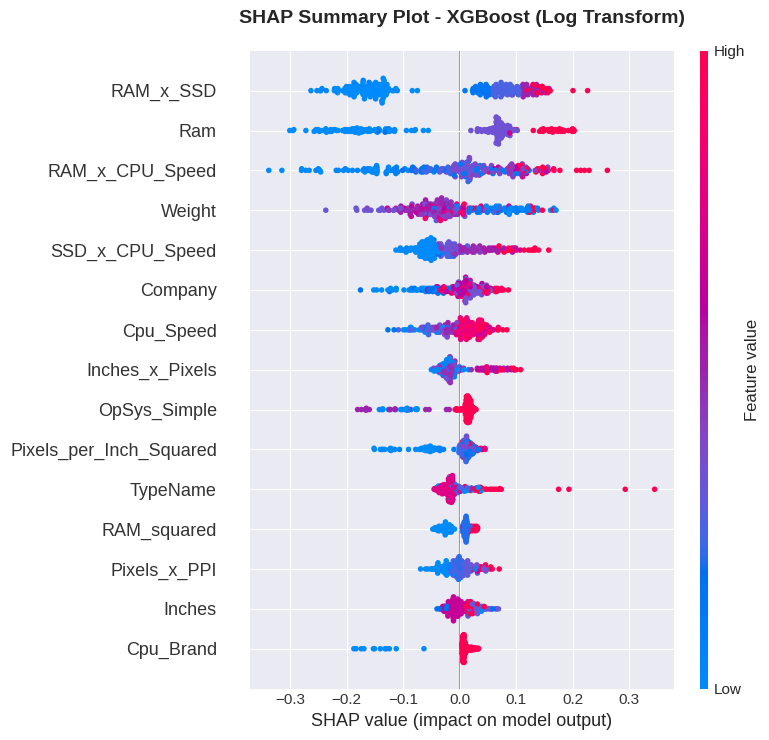


📊 VISUALIZAÇÃO 2: FEATURE IMPORTANCE (BAR)

   Este gráfico mostra a importância média absoluta de cada feature.
   Barras maiores = features com maior impacto nas previsões.



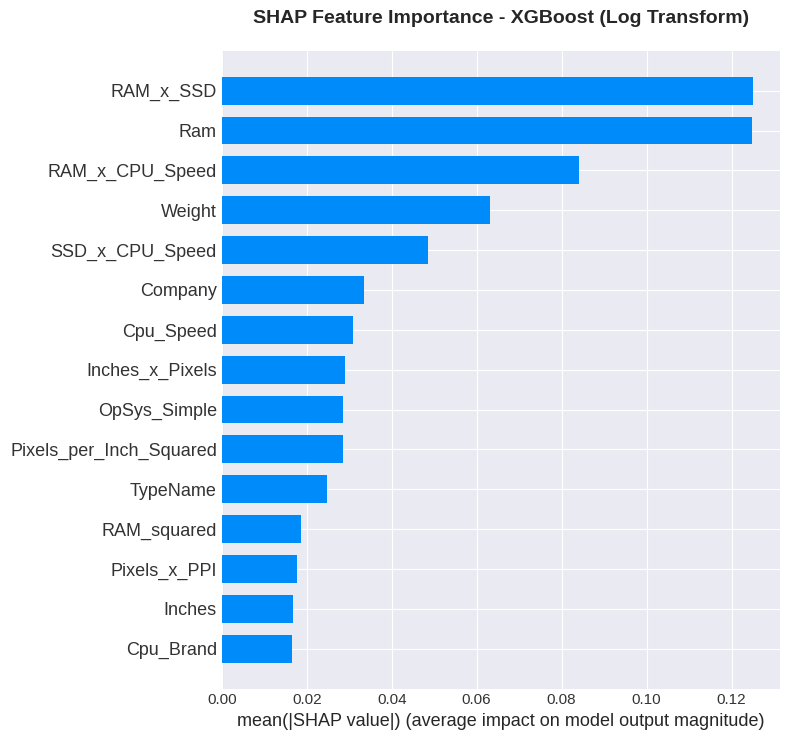


📊 VISUALIZAÇÃO 3: WATERFALL PLOT (EXPLICAÇÃO INDIVIDUAL)

   Este gráfico explica UMA previsão específica:
   • Mostra contribuição de cada feature para o valor final
   • Base value = previsão média do modelo
   • Features em vermelho aumentam o preço
   • Features em azul diminuem o preço



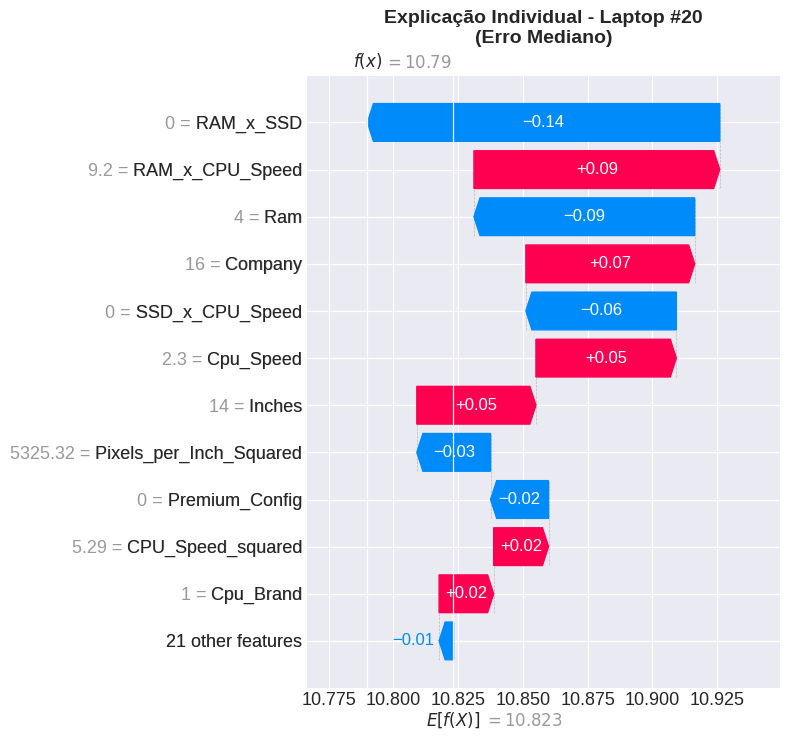


   📌 Laptop analisado (índice 20):
      • Preço Real: 48,751.20 INR
      • Preço Previsto: 10.79 INR
      • Erro: 48,740.41 INR

📊 VISUALIZAÇÃO 4: DEPENDENCE PLOTS

   Estes gráficos mostram como o valor de uma feature
   afeta a previsão de preço, considerando interações
   com outras features.



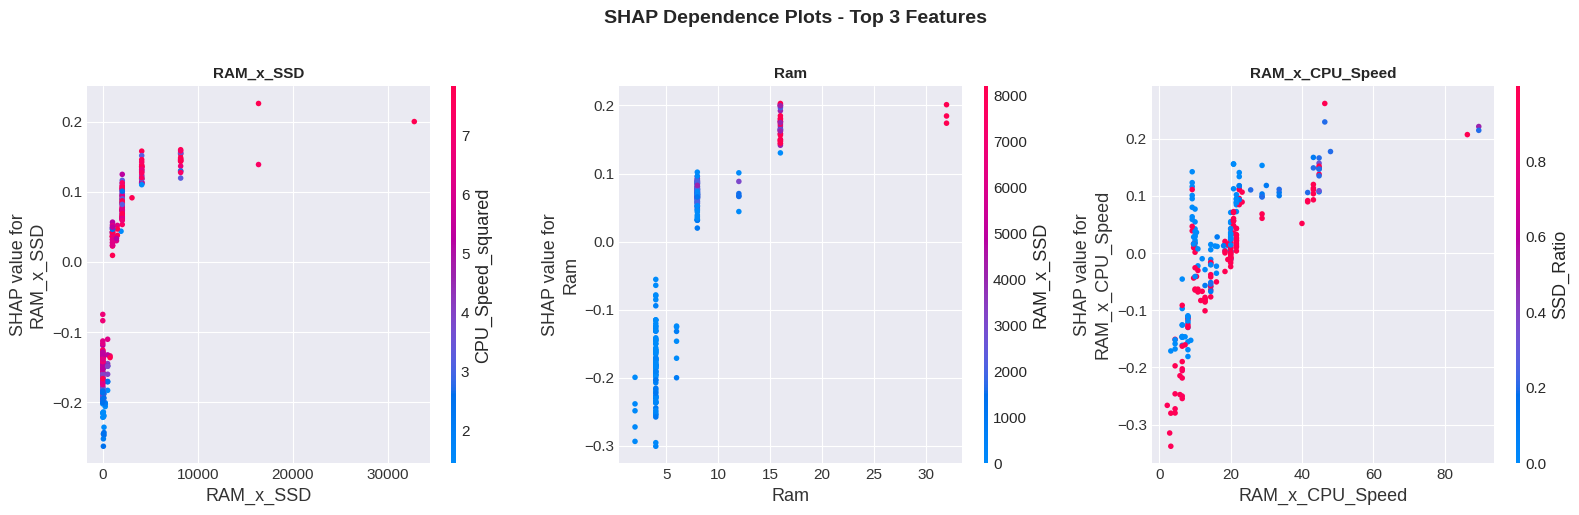


🔗 ANÁLISE DE INTERAÇÕES ENTRE FEATURES

   🔝 Top 5 Interações mais fortes:

      Ram                  ↔ RAM_squared          (corr: 0.991)
      Cpu_Speed            ↔ CPU_Speed_squared    (corr: 0.954)
      Cpu_Speed            ↔ RAM_x_CPU_Speed      (corr: 0.820)
      Total_Storage        ↔ Storage_x_RAM        (corr: 0.805)
      RAM_x_CPU_Speed      ↔ CPU_Speed_squared    (corr: 0.804)

📋 RESUMO DA ANÁLISE SHAP

   ┌─────────────────────────────────────────────────────────┐
   │            ANÁLISE SHAP - RESUMO EXECUTIVO             │
   ├─────────────────────────────────────────────────────────┤
   │                                                         │
   │  🏆 Modelo: XGBoost (Log Transform)                  │
   │  📊 MAE: 8,168.71 INR                                │
   │                                                         │
   │  📈 Features Analisadas: 32                           │
   │  🔍 Amostras Analisadas: 254                          │
   │                    

In [ ]:
# -*- coding: utf-8 -*-
"""
## 13. INTERPRETABILIDADE COM SHAP
Versão adaptativa que detecta automaticamente o melhor modelo disponível.
Gera 4 visualizações SHAP para explicar as previsões do modelo.
"""

# @title
# ==========================================
# 13. INTERPRETABILIDADE COM SHAP - VERSÃO ADAPTATIVA
# ==========================================

# Instalar SHAP se necessário
try:
    import shap
except ImportError:
    print("⚙️ Instalando SHAP...")
    !pip install shap -q
    import shap

print("\n" + "="*80)
print("🔍 SEÇÃO 13: ANÁLISE DE INTERPRETABILIDADE COM SHAP")
print("="*80)

print("""
   📚 SHAP (SHapley Additive exPlanations)

   O SHAP é baseado em Shapley Values da Teoria dos Jogos.
   Para cada previsão, calcula a contribuição exata de cada feature.

   Vantagens:
   • Explicações consistentes e localmente precisas
   • Captura interações complexas entre features
   • Visualizações intuitivas de importância
""")

# ==========================================
# 13.1 DETECÇÃO AUTOMÁTICA DO MELHOR MODELO
# ==========================================

print("\n" + "="*80)
print("🔎 DETECTANDO MODELOS DISPONÍVEIS")
print("="*80)

modelos_disponiveis = {}

# 1. XGBoost com Log Transformation
if 'xgb_log' in globals() and 'test_mae_log' in globals():
    X_test_shap = X_test.copy()
    if 'Gpu_Dedicated' in X_test_shap.columns:
        X_test_shap['Gpu_Dedicated'] = X_test_shap['Gpu_Dedicated'].astype(int)

    modelos_disponiveis['XGBoost (Log Transform)'] = {
        'model': xgb_log,
        'X_test': X_test_shap,
        'mae': test_mae_log,
        'tipo': 'tree'
    }
    print(f"   ✅ XGBoost Log Transform: MAE = {test_mae_log:,.2f}")

# 2. XGBoost GridSearchCV
if 'xgb_grid_model' in globals() and 'test_mae_xgb_grid' in globals():
    X_test_shap = X_test.copy()
    if 'Gpu_Dedicated' in X_test_shap.columns:
        X_test_shap['Gpu_Dedicated'] = X_test_shap['Gpu_Dedicated'].astype(int)

    modelos_disponiveis['XGBoost (GridSearch)'] = {
        'model': xgb_grid_model,
        'X_test': X_test_shap,
        'mae': test_mae_xgb_grid,
        'tipo': 'tree'
    }
    print(f"   ✅ XGBoost GridSearch: MAE = {test_mae_xgb_grid:,.2f}")

# 3. XGBoost Original
if 'xgb_model' in globals() and 'test_mae_xgb' in globals():
    X_test_shap = X_test.copy()
    if 'Gpu_Dedicated' in X_test_shap.columns:
        X_test_shap['Gpu_Dedicated'] = X_test_shap['Gpu_Dedicated'].astype(int)

    modelos_disponiveis['XGBoost (Original)'] = {
        'model': xgb_model,
        'X_test': X_test_shap,
        'mae': test_mae_xgb,
        'tipo': 'tree'
    }
    print(f"   ✅ XGBoost Original: MAE = {test_mae_xgb:,.2f}")

# 4. Random Forest GridSearchCV
if 'rf_grid_model' in globals() and 'test_mae_rf_grid' in globals():
    modelos_disponiveis['Random Forest (GridSearch)'] = {
        'model': rf_grid_model,
        'X_test': X_test,
        'mae': test_mae_rf_grid,
        'tipo': 'tree'
    }
    print(f"   ✅ Random Forest GridSearch: MAE = {test_mae_rf_grid:,.2f}")

# 5. Random Forest Otimizado (RandomizedSearch)
if 'rf_best_model' in globals() and 'test_mae_rf_opt' in globals():
    modelos_disponiveis['Random Forest (Otimizado)'] = {
        'model': rf_best_model,
        'X_test': X_test,
        'mae': test_mae_rf_opt,
        'tipo': 'tree'
    }
    print(f"   ✅ Random Forest Otimizado: MAE = {test_mae_rf_opt:,.2f}")

# 6. Random Forest Inicial
if 'rf_model' in globals() and 'test_mae_rf' in globals():
    modelos_disponiveis['Random Forest (Inicial)'] = {
        'model': rf_model,
        'X_test': X_test,
        'mae': test_mae_rf,
        'tipo': 'tree'
    }
    print(f"   ✅ Random Forest Inicial: MAE = {test_mae_rf:,.2f}")

# 7. Gradient Boosting
if 'gb_model' in globals() and 'test_mae_gb' in globals():
    modelos_disponiveis['Gradient Boosting'] = {
        'model': gb_model,
        'X_test': X_test,
        'mae': test_mae_gb,
        'tipo': 'tree'
    }
    print(f"   ✅ Gradient Boosting: MAE = {test_mae_gb:,.2f}")

# ==========================================
# 13.2 SELECIONAR MELHOR MODELO PARA ANÁLISE
# ==========================================

if not modelos_disponiveis:
    print("\n❌ ERRO: Nenhum modelo compatível encontrado!")
    print("   Execute as seções 9 e 10 primeiro para treinar os modelos.")
else:
    # Selecionar o modelo com menor MAE
    melhor_nome = min(modelos_disponiveis.keys(),
                      key=lambda x: modelos_disponiveis[x]['mae'])
    melhor_info = modelos_disponiveis[melhor_nome]

    print(f"\n" + "="*80)
    print(f"🏆 MODELO SELECIONADO PARA ANÁLISE SHAP")
    print("="*80)
    print(f"""
   📌 Modelo: {melhor_nome}
   📊 MAE: {melhor_info['mae']:,.2f} INR
   🔧 Tipo: {melhor_info['tipo']}
""")

    # ==========================================
    # 13.3 CALCULAR VALORES SHAP
    # ==========================================

    print("="*80)
    print("⚙️ CALCULANDO VALORES SHAP")
    print("="*80)
    print("\n   Isso pode levar alguns minutos dependendo do tamanho do dataset...")

    modelo_shap = melhor_info['model']
    X_shap = melhor_info['X_test']

    # Limitar amostra para performance (máximo 500 instâncias)
    n_samples = min(500, len(X_shap))
    X_shap_sample = X_shap.sample(n=n_samples, random_state=42)

    print(f"   📊 Analisando {n_samples} amostras de {len(X_shap)} total")

    # Criar explainer apropriado
    if melhor_info['tipo'] == 'tree':
        explainer = shap.TreeExplainer(modelo_shap)
        shap_values = explainer.shap_values(X_shap_sample)
    else:
        # Fallback para outros tipos de modelo
        explainer = shap.Explainer(modelo_shap, X_shap_sample)
        shap_values = explainer(X_shap_sample)

    print("   ✅ Valores SHAP calculados com sucesso!")

    # ==========================================
    # 13.4 CALCULAR IMPORTÂNCIA MÉDIA
    # ==========================================

    print("\n" + "="*80)
    print("📊 IMPORTÂNCIA DAS FEATURES (SHAP)")
    print("="*80)

    # Calcular importância média absoluta
    shap_importance = pd.DataFrame({
        'Feature': X_shap_sample.columns,
        'SHAP_Importance': np.abs(shap_values).mean(axis=0)
    }).sort_values('SHAP_Importance', ascending=False)

    # Calcular percentual
    total_importance = shap_importance['SHAP_Importance'].sum()
    shap_importance['Percentual'] = (shap_importance['SHAP_Importance'] / total_importance * 100)
    shap_importance['Acumulado'] = shap_importance['Percentual'].cumsum()

    # Top 10 features
    top_10 = shap_importance.head(10)

    print("\n   🏆 TOP 10 Features por Importância SHAP:\n")
    print(f"   {'Rank':<6} {'Feature':<30} {'Importância':>12} {'%':>8} {'Acum.':>8}")
    print("   " + "-"*66)

    for idx, (_, row) in enumerate(top_10.iterrows(), 1):
        bar = "█" * int(row['Percentual'] / 3) + "░" * (15 - int(row['Percentual'] / 3))
        print(f"   {idx:<6} {row['Feature']:<30} {row['SHAP_Importance']:>12.2f} {row['Percentual']:>7.1f}% {row['Acumulado']:>7.1f}%")

    # Insights sobre concentração
    top_2_pct = shap_importance.head(2)['Percentual'].sum()
    top_5_pct = shap_importance.head(5)['Percentual'].sum()

    print(f"""

   💡 Insights:
      • Top 2 features explicam {top_2_pct:.1f}% do modelo
      • Top 5 features explicam {top_5_pct:.1f}% do modelo
      • Feature mais importante: {top_10.iloc[0]['Feature']}
""")

    # ==========================================
    # 13.5 VISUALIZAÇÃO 1: SUMMARY PLOT (BEESWARM)
    # ==========================================

    print("="*80)
    print("📊 VISUALIZAÇÃO 1: SUMMARY PLOT (BEESWARM)")
    print("="*80)
    print("""
   Este gráfico mostra:
   • Cada ponto = uma previsão individual
   • Posição X = impacto SHAP no preço previsto
   • Cor = valor da feature (vermelho = alto, azul = baixo)
""")

    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values, X_shap_sample, show=False, max_display=15)
    plt.title(f'SHAP Summary Plot - {melhor_nome}', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    plt.close()

    # ==========================================
    # 13.6 VISUALIZAÇÃO 2: BAR PLOT (IMPORTÂNCIA)
    # ==========================================

    print("\n" + "="*80)
    print("📊 VISUALIZAÇÃO 2: FEATURE IMPORTANCE (BAR)")
    print("="*80)
    print("""
   Este gráfico mostra a importância média absoluta de cada feature.
   Barras maiores = features com maior impacto nas previsões.
""")

    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_shap_sample, plot_type="bar", show=False, max_display=15)
    plt.title(f'SHAP Feature Importance - {melhor_nome}', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    plt.close()

    # ==========================================
    # 13.7 VISUALIZAÇÃO 3: WATERFALL (EXPLICAÇÃO INDIVIDUAL)
    # ==========================================

    print("\n" + "="*80)
    print("📊 VISUALIZAÇÃO 3: WATERFALL PLOT (EXPLICAÇÃO INDIVIDUAL)")
    print("="*80)
    print("""
   Este gráfico explica UMA previsão específica:
   • Mostra contribuição de cada feature para o valor final
   • Base value = previsão média do modelo
   • Features em vermelho aumentam o preço
   • Features em azul diminuem o preço
""")

    # Selecionar uma amostra interessante (laptop com maior erro)
    y_pred_sample = modelo_shap.predict(X_shap_sample)
    y_real_sample = y_test.loc[X_shap_sample.index].values
    erros = np.abs(y_real_sample - y_pred_sample)

    # Índice do laptop com erro mediano (mais representativo)
    idx_mediano = np.argsort(erros)[len(erros)//2]

    plt.figure(figsize=(12, 8))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx_mediano],
            base_values=explainer.expected_value,
            data=X_shap_sample.iloc[idx_mediano],
            feature_names=X_shap_sample.columns.tolist()
        ),
        show=False,
        max_display=12
    )
    plt.title(f'Explicação Individual - Laptop #{idx_mediano}\n(Erro Mediano)',
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close()

    print(f"""
   📌 Laptop analisado (índice {idx_mediano}):
      • Preço Real: {y_real_sample[idx_mediano]:,.2f} INR
      • Preço Previsto: {y_pred_sample[idx_mediano]:,.2f} INR
      • Erro: {erros[idx_mediano]:,.2f} INR
""")

    # ==========================================
    # 13.8 VISUALIZAÇÃO 4: DEPENDENCE PLOT
    # ==========================================

    print("="*80)
    print("📊 VISUALIZAÇÃO 4: DEPENDENCE PLOTS")
    print("="*80)
    print("""
   Estes gráficos mostram como o valor de uma feature
   afeta a previsão de preço, considerando interações
   com outras features.
""")

    # Top 3 features para dependence plot
    top_3_features = top_10.head(3)['Feature'].tolist()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for idx, feature in enumerate(top_3_features):
        plt.sca(axes[idx])
        shap.dependence_plot(
            feature,
            shap_values,
            X_shap_sample,
            interaction_index='auto',
            show=False,
            ax=axes[idx]
        )
        axes[idx].set_title(f'{feature}', fontsize=11, fontweight='bold')

    plt.suptitle(f'SHAP Dependence Plots - Top 3 Features', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    plt.close()

    # ==========================================
    # 13.9 ANÁLISE DE INTERAÇÕES
    # ==========================================

    print("\n" + "="*80)
    print("🔗 ANÁLISE DE INTERAÇÕES ENTRE FEATURES")
    print("="*80)

    # Calcular correlação entre valores SHAP
    shap_df = pd.DataFrame(shap_values, columns=X_shap_sample.columns)
    shap_corr = shap_df.corr()

    # Encontrar as maiores interações (excluindo diagonal)
    np.fill_diagonal(shap_corr.values, 0)

    # Top interações
    interacoes = []
    for i in range(len(shap_corr.columns)):
        for j in range(i+1, len(shap_corr.columns)):
            interacoes.append({
                'Feature 1': shap_corr.columns[i],
                'Feature 2': shap_corr.columns[j],
                'Correlação': abs(shap_corr.iloc[i, j])
            })

    df_interacoes = pd.DataFrame(interacoes).sort_values('Correlação', ascending=False)

    print("\n   🔝 Top 5 Interações mais fortes:\n")
    for idx, row in df_interacoes.head(5).iterrows():
        print(f"      {row['Feature 1'][:20]:<20} ↔ {row['Feature 2'][:20]:<20} (corr: {row['Correlação']:.3f})")

    # ==========================================
    # 13.10 RESUMO FINAL DA ANÁLISE SHAP
    # ==========================================

    print("\n" + "="*80)
    print("📋 RESUMO DA ANÁLISE SHAP")
    print("="*80)

    print(f"""
   ┌─────────────────────────────────────────────────────────┐
   │            ANÁLISE SHAP - RESUMO EXECUTIVO             │
   ├─────────────────────────────────────────────────────────┤
   │                                                         │
   │  🏆 Modelo: {melhor_nome[:40]:<40} │
   │  📊 MAE: {melhor_info['mae']:,.2f} INR                                │
   │                                                         │
   │  📈 Features Analisadas: {X_shap_sample.shape[1]:<25}    │
   │  🔍 Amostras Analisadas: {n_samples:<25}    │
   │                                                         │
   │  💡 Principais Descobertas:                            │
   │                                                         │
   │     1️⃣ {top_10.iloc[0]['Feature'][:35]:<35}      │
   │        → {top_10.iloc[0]['Percentual']:.1f}% da importância total                │
   │                                                         │
   │     2️⃣ {top_10.iloc[1]['Feature'][:35]:<35}      │
   │        → {top_10.iloc[1]['Percentual']:.1f}% da importância total                │
   │                                                         │
   │     3️⃣ {top_10.iloc[2]['Feature'][:35]:<35}      │
   │        → {top_10.iloc[2]['Percentual']:.1f}% da importância total                │
   │                                                         │
   │  📊 Concentração: Top 5 = {top_5_pct:.1f}% do modelo            │
   │                                                         │
   └─────────────────────────────────────────────────────────┘
""")

    # Salvar variáveis para uso posterior
    shap_feature_importance = shap_importance
    shap_top_features = top_10

    print("\n" + "="*80)
    print("✅ SEÇÃO 13 CONCLUÍDA - ANÁLISE SHAP FINALIZADA")
    print("="*80)
    print("""
   📊 4 visualizações SHAP geradas:
      1. Summary Plot (Beeswarm)
      2. Feature Importance (Bar)
      3. Waterfall Plot (Individual)
      4. Dependence Plots (Top 3)

   💡 Use esses insights para:
      • Explicar previsões para stakeholders
      • Identificar features redundantes
      • Guiar próximas iterações de feature engineering
""")